# Optimisation of Photoanode Architecture and Electrolyte Composition in Iodide-based Dye-Sensitized Solar Cells for Indoor Photovoltaics

This notebook applies **Bayesian optimisation** to identify electrolyte compositions that maximise the performance of dye-sensitised solar cells (DSSCs).

**Problem:** We have a set of experimental measurements in which five electrolyte components — I₂, LiI, BMII, TBP, and GuSCN — were varied, and three performance metrics were recorded: power conversion efficiency (PCE), open-circuit voltage (Voc), and short-circuit current density (Jsc). Running experiments is costly, so we use the existing data to *intelligently* suggest the next compositions most likely to improve performance.

**Approach:** A *Gaussian Process* (GP) is used as a surrogate model — it learns the relationship between composition and performance from the existing data and predicts outcomes at untested points. Bayesian optimisation then uses this model to balance *exploration* (trying unknown regions) and *exploitation* (refining known good regions) when proposing new experiments.

In [117]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ConstantKernel, WhiteKernel
import warnings
import matplotlib.pyplot as plt
from bayes_opt import BayesianOptimization
import seaborn as sns
import pandas as pd
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score, mean_absolute_error


import io
warnings.filterwarnings("ignore")


In [59]:
df = pd.read_csv('./data-bo-dssc.tsv', sep='\t', decimal=',')
X = df[['I2', 'LiI', 'BMII', 'TBP', 'GuSCN']].values
y = df['PCE(%)'].values

## 1. Exploratory Data Analysis

Before running the optimisation, we visualise the dataset to understand how the five input components relate to each other and to the performance metrics. Pairplots show scatter plots for every pair of variables, with kernel density estimates (KDE) on the diagonal — these reveal the distribution of each variable and potential correlations between them.

In [60]:
df_plot = pd.read_csv('./data-bo-dssc.tsv', sep='\t', decimal=',')
df_plot.drop(columns=['PCE(%)', 'Voc(V)', 'Jsc(uAcm-2)'], inplace=True)


In [61]:
print("\n" + "="*80)
print("Range of each parameter:")
param_cols = ['I2', 'LiI', 'BMII', 'TBP', 'GuSCN']
for col in param_cols:
    print(f"{col}: {df[col].min()} - {df[col].max()}")
    


Range of each parameter:
I2: 0.01 - 0.04
LiI: 0.0 - 0.3
BMII: 0.5 - 1.5
TBP: 0.5 - 1.5
GuSCN: 0.0 - 0.2


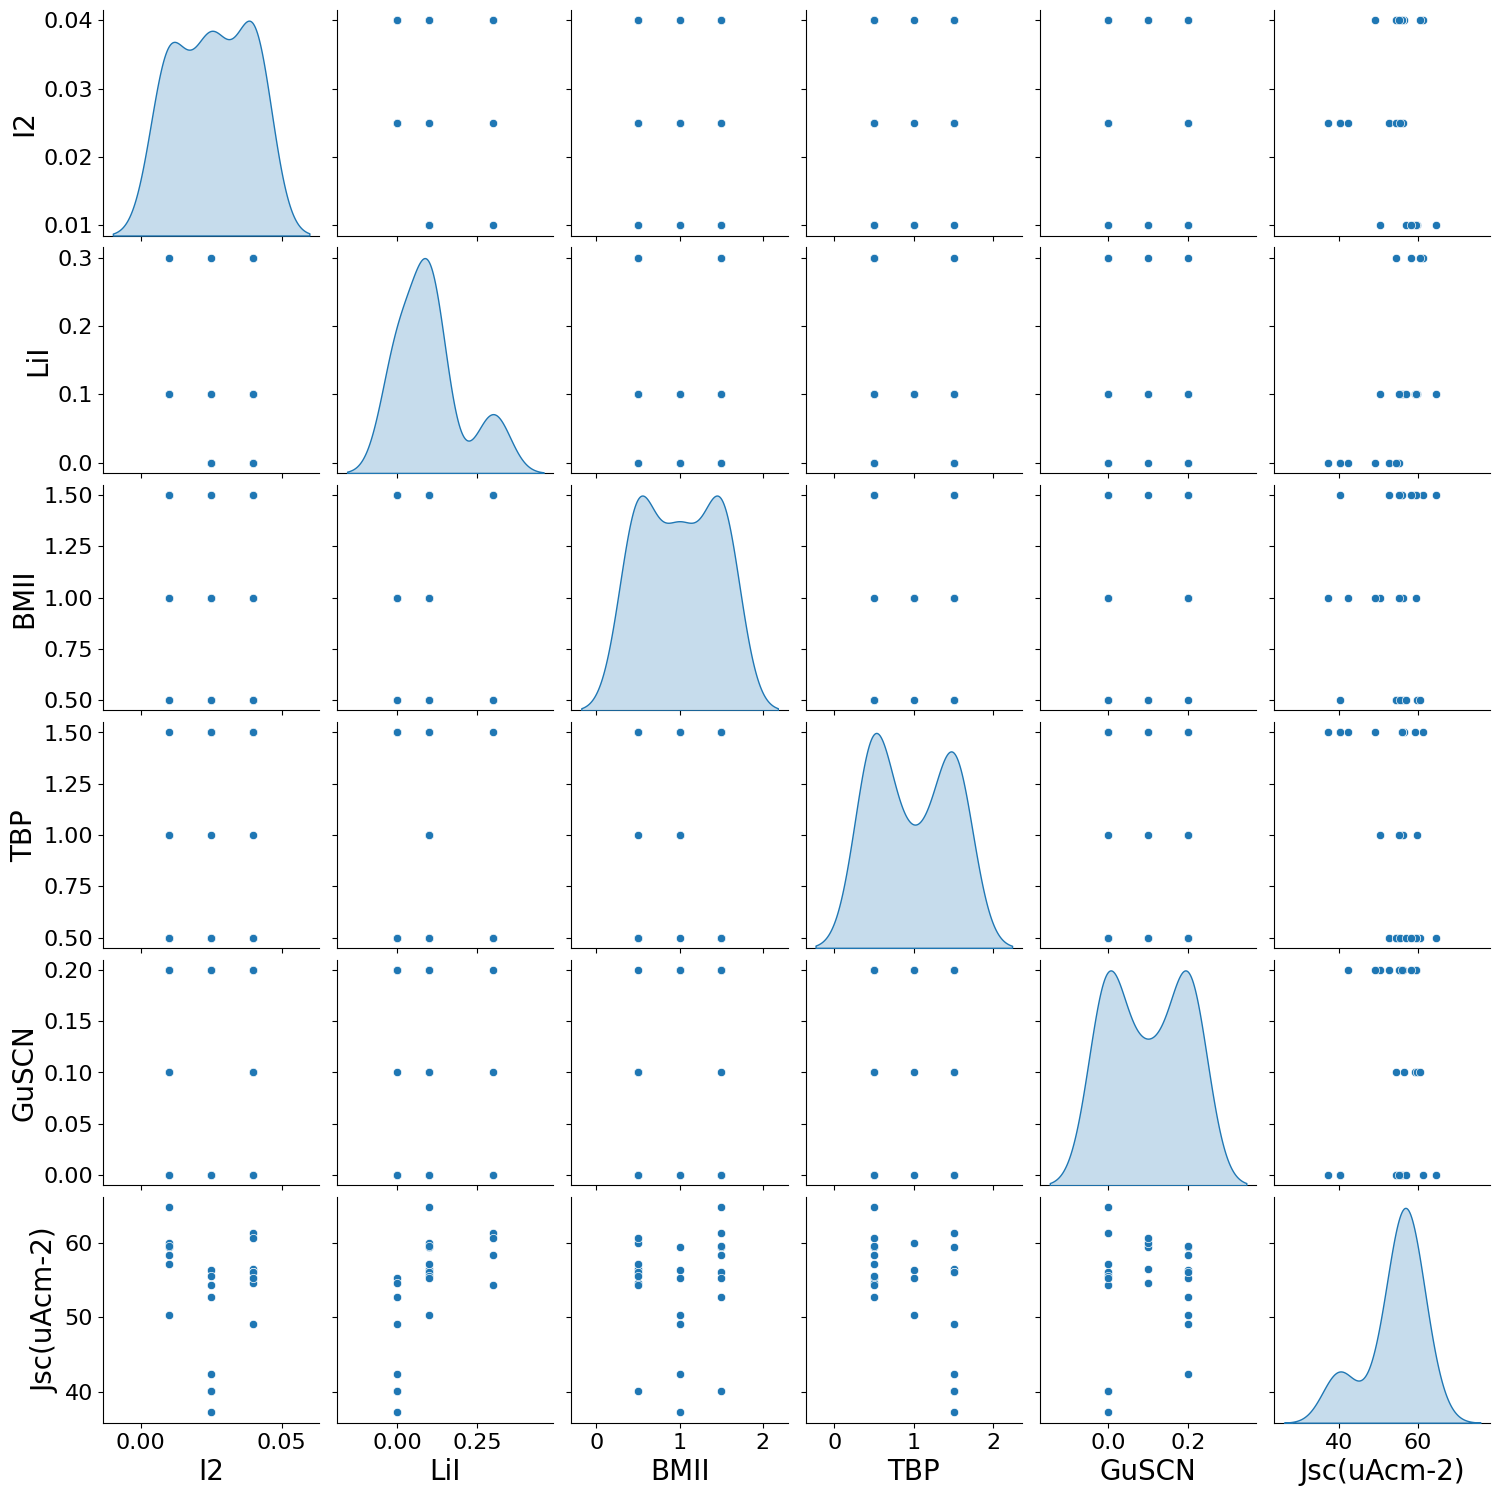

In [62]:
param_cols = ['I2', 'LiI', 'BMII', 'TBP', 'GuSCN']
targets = [('PCE(%)', 'pce'), ('Jsc(uAcm-2)', 'jsc'), ('Voc(V)', 'voc')]

df_plot = df[param_cols + ['Jsc(uAcm-2)']].copy()
g = sns.pairplot(df_plot, diag_kind='kde')

# Iterate over all subplots to adjust font sizes
for ax in g.axes.flatten():
    if ax:
        # Increase axis label sizes (x and y)
        ax.set_xlabel(ax.get_xlabel(), fontsize=20)
        ax.set_ylabel(ax.get_ylabel(), fontsize=20)
        
        # Increase tick label sizes (numbers on axes)
        ax.tick_params(axis='both', labelsize=16)

plt.show()

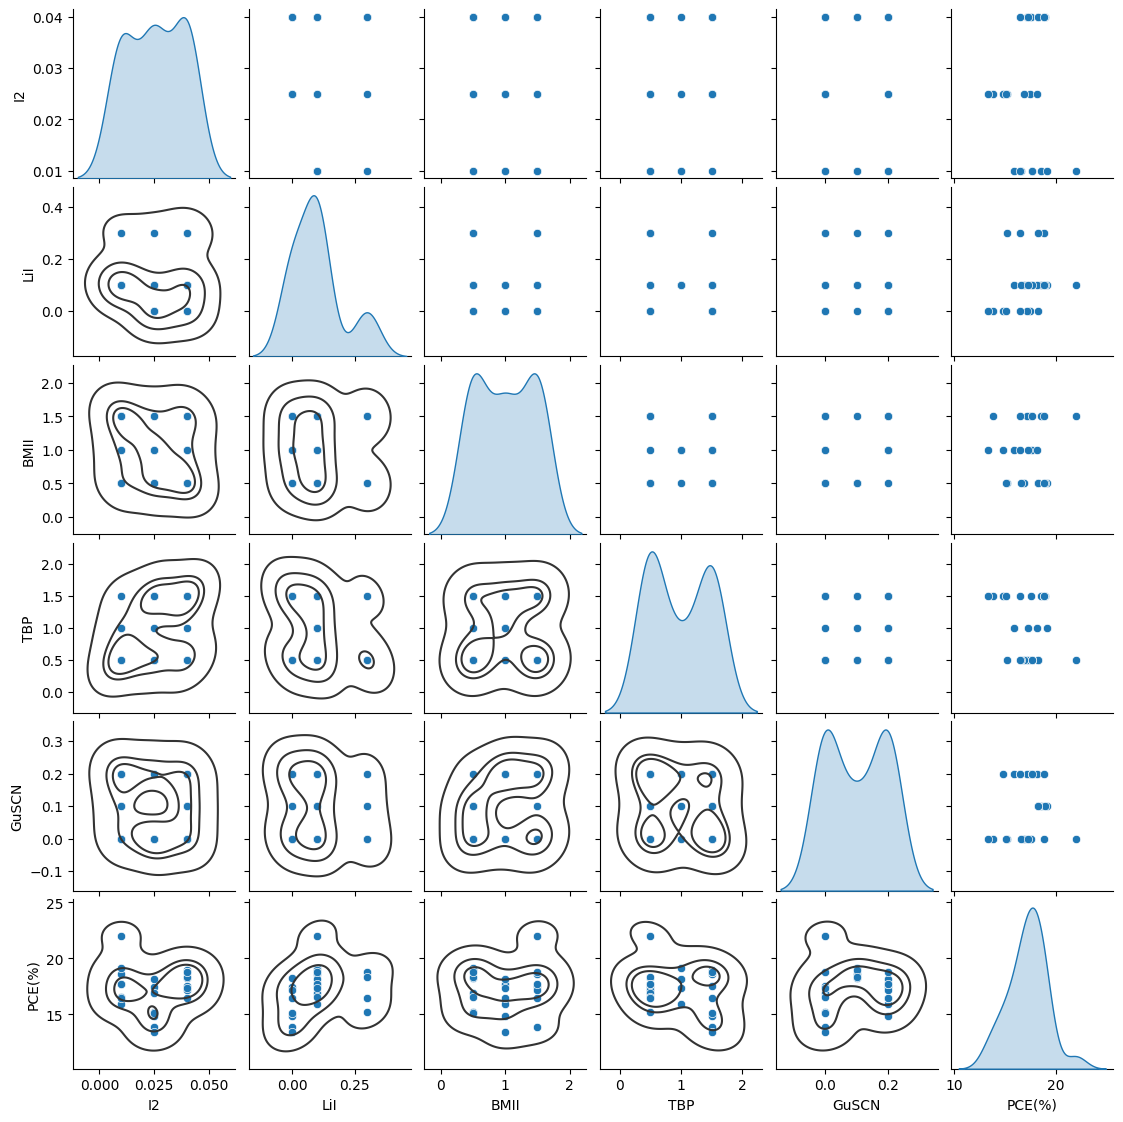

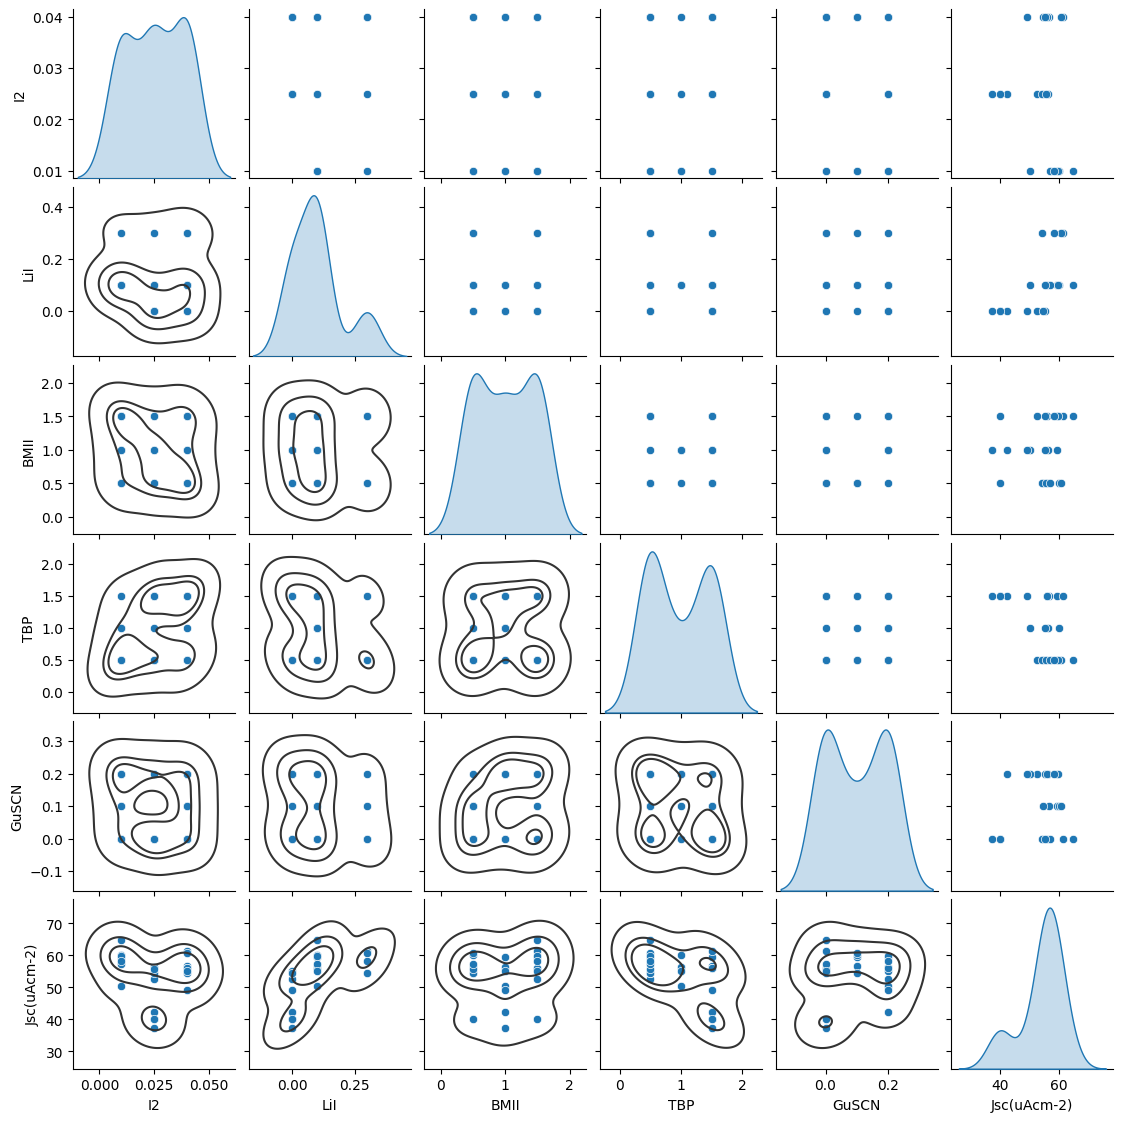

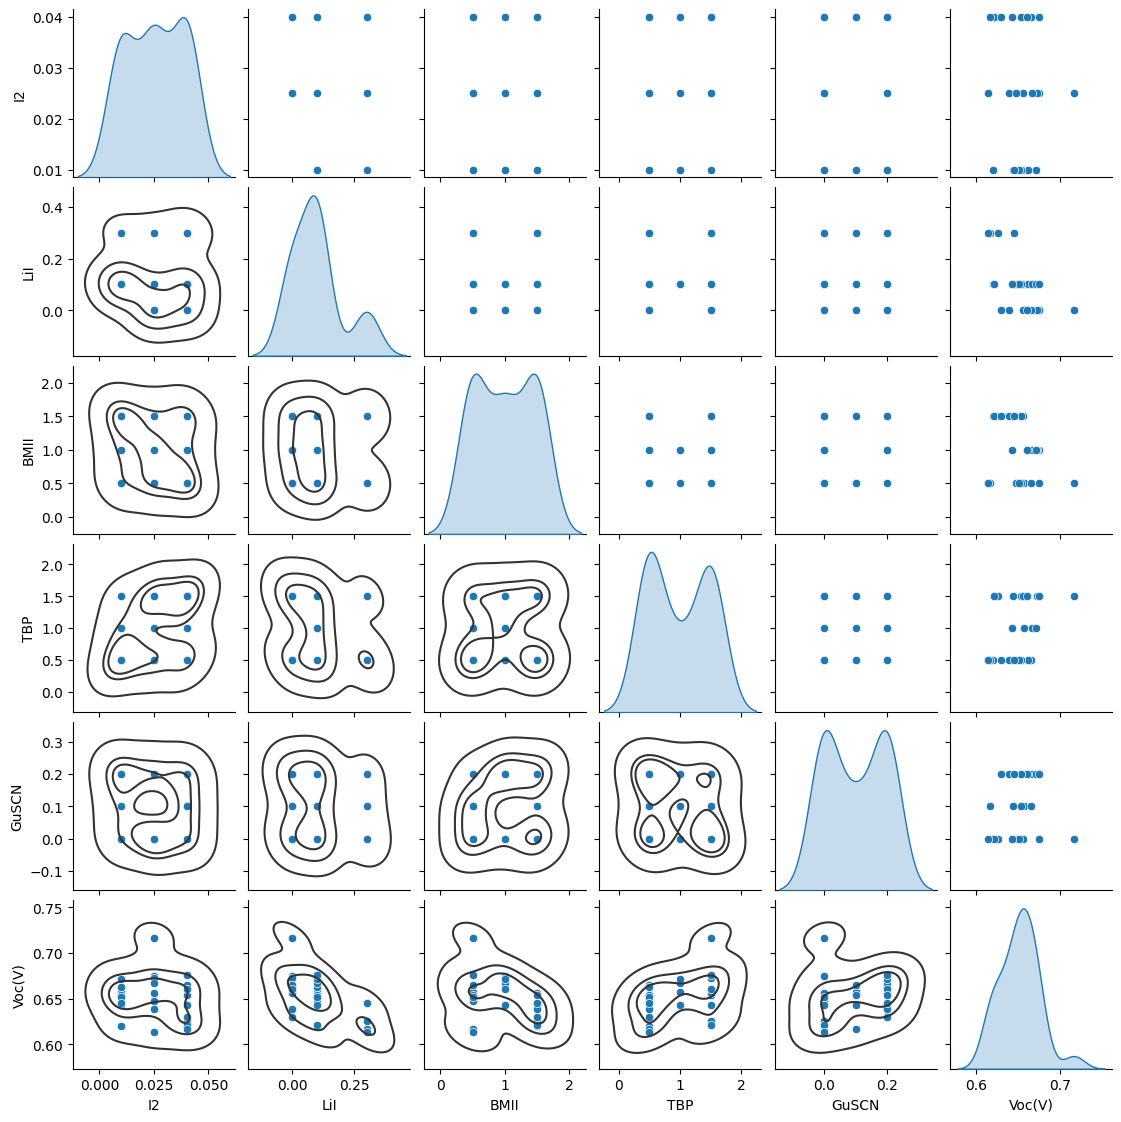

In [63]:
# Separate pairplots for each output variable (PCE, Jsc, Voc)
param_cols = ['I2', 'LiI', 'BMII', 'TBP', 'GuSCN']
targets = [('PCE(%)', 'pce'), ('Jsc(uAcm-2)', 'jsc'), ('Voc(V)', 'voc')]

# Create a list to store the generated images
imgs = []

for col, short in targets:
    df_plot = df[param_cols + [col]].copy()
    g = sns.pairplot(df_plot, diag_kind='kde')
    g.map_lower(sns.kdeplot, levels=4, color=".2")
    
    # Adjust size and title
    orig_size = g.fig.get_size_inches()
    g.fig.set_size_inches(orig_size * 0.75)
    #g.fig.suptitle(f'Pairplot - {col}', y=1.02)
    #g.savefig(f'pairplot_measured_data_{short}.png', dpi=300, bbox_inches='tight')
    
    



## 2. Bayesian Optimisation — PCE

We now apply Bayesian optimisation to maximise the **power conversion efficiency (PCE)**. The steps are:

1. **Define the search space** — specify physically meaningful concentration bounds for each component.
2. **Build a surrogate model** — a Gaussian Process is fitted to the existing data; it predicts both the expected performance and its uncertainty at any untested point.
3. **Register prior observations** — all existing experiments are fed to the optimiser as their starting knowledge.
4. **Run the optimisation loop** — in each iteration, the optimiser uses an *acquisition function* to select the next candidate point, balancing high predicted performance with high uncertainty.
5. **Extract candidates** — configurations whose predicted PCE exceeds the current experimental maximum are retained as recommendations for future experiments.

In [64]:
bounds = {'I2': (0, 0.05),
'LiI': (0, 0.5),
'BMII': (0, 1.5),
'TBP': (0, 2),
'GuSCN': (0, 0.5)}

In [65]:
# Verify the current maximum value of PCE
current_max = y.max()
print(f"Current maximum value of PCE(%): {current_max:.4f}")
print(f"Configuration with maximum PCE:")
max_idx = y.argmax()
for i, param in enumerate(['I2', 'LiI', 'BMII', 'TBP', 'GuSCN']):
    print(f"  {param}: {X[max_idx, i]:.4f}")

Current maximum value of PCE(%): 21.9940
Configuration with maximum PCE:
  I2: 0.0100
  LiI: 0.1000
  BMII: 1.5000
  TBP: 0.5000
  GuSCN: 0.0000


In [66]:
# Define the objective function for Bayesian optimisation
def black_box_function(I2, LiI, BMII, TBP, GuSCN):
    """
    Function that the optimiser will attempt to maximise.
    Employs a Gaussian Process fitted to the existing data.
    """
    # Create the point to be evaluated
    x_test = np.array([[I2, LiI, BMII, TBP, GuSCN]])
    
    # Fit the GP using all available data
    kernel = ConstantKernel(1.0) * Matern(length_scale=1.0, nu=2.5)
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)
    gp.fit(X, y)
    
    # Predict the value
    y_pred, sigma = gp.predict(x_test, return_std=True)
    
    return y_pred[0]

In [67]:
# Initialise the Bayesian optimiser
optimizer = BayesianOptimization(
    f=black_box_function,
    pbounds=bounds,
    random_state=42,
    verbose=2
)

# Register the existing data as initial observations
for i in range(len(X)):
    optimizer.register(
        params={
            'I2': X[i, 0],
            'LiI': X[i, 1],
            'BMII': X[i, 2],
            'TBP': X[i, 3],
            'GuSCN': X[i, 4]
        },
        target=y[i]
    )

print(f"\nInitial data registered: {len(X)} experiments")

| 1         | 18.5585   | 0.01      | 0.1       | 1.5       | 1.5       | 0.1       |
| 2         | 19.1205   | 0.01      | 0.1       | 0.5       | 1.0       | 0.1       |
| 3         | 17.448    | 0.025     | 0.0       | 1.5       | 0.5       | 0.2       |
| 4         | 18.9755   | 0.04      | 0.1       | 0.5       | 1.5       | 0.1       |
| 5         | 18.809    | 0.04      | 0.3       | 1.5       | 1.5       | 0.0       |
| 6         | 13.852    | 0.025     | 0.0       | 1.5       | 1.5       | 0.0       |
| 7         | 13.394    | 0.025     | 0.0       | 1.0       | 1.5       | 0.0       |
| 8         | 14.8485   | 0.025     | 0.0       | 1.0       | 1.5       | 0.2       |
| 9         | 21.994    | 0.01      | 0.1       | 1.5       | 0.5       | 0.0       |
| 10        | 17.546    | 0.04      | 0.1       | 1.5       | 1.5       | 0.0       |
| 11        | 17.136    | 0.04      | 0.0       | 1.5       | 0.5       | 0.2       |
| 12        | 18.251    | 0.04      | 0.0       | 0.5 

In [68]:
# Run Bayesian optimisation iterations to identify novel candidate configurations
optimizer.maximize(
    init_points=0,  # Initial observations already registered
    n_iter=100,       # 100 new candidate configurations
)

|   iter    |  target   |    I2     |    LiI    |   BMII    |    TBP    |   GuSCN   |
-------------------------------------------------------------------------------------
| 26        | 16.830916 | 0.0077997 | 0.4328504 | 1.1078565 | 1.4004200 | 0.1211309 |
| 27        | 19.166309 | 0.0108759 | 0.1005279 | 0.4890427 | 1.0209514 | 0.0992886 |
| 28        | 19.756324 | 0.0139869 | 0.1119451 | 0.4947675 | 1.0116046 | 0.1238127 |
| 29        | 21.942158 | 0.0104979 | 0.1141256 | 1.4965307 | 0.5111541 | 0.0011719 |
| 30        | 21.641498 | 0.0197007 | 0.1056954 | 1.4844013 | 0.4998160 | 0.0178975 |
| 31        | 21.860972 | 0.0099691 | 0.1250931 | 1.4956534 | 0.4805415 | 0.0014871 |
| 32        | 22.011194 | 0.0       | 0.1098815 | 1.4646323 | 0.4927808 | 0.0       |
| 33        | 17.576920 | 0.0125045 | 0.1611063 | 0.8505645 | 0.8331536 | 0.1236240 |
| 34        | 20.368450 | 0.0361397 | 0.3479348 | 0.4651889 | 1.4219365 | 0.0739343 |
| 35        | 18.650504 | 0.0068097 | 0.3632683 | 0.44

In [69]:
# Extract proposed configurations that surpass the current maximum
print("\n" + "="*80)
print("PROPOSED CONFIGURATIONS FOR IMPROVING PCE(%)")
print("="*80)
current_max = y.max()
print(f"Current maximum in the dataset: {current_max:.4f}%")
print("="*80)

proposed_combinations = []

# Retrieve only the last 100 iterations (the new proposals)
all_iterations = len(optimizer.res)
start_idx = len(X)  # Start after the original data

# Filter only the configurations that surpass the current maximum
for res in optimizer.res[start_idx:]:
    params = res['params']
    target = res['target']
    
    # Only include if the predicted PCE exceeds the current maximum
    if target > current_max:
        combination = {
            'I2': params['I2'],
            'LiI': params['LiI'],
            'BMII': params['BMII'],
            'TBP': params['TBP'],
            'GuSCN': params['GuSCN'],
            'PCE_predicted(%)': target,
            'Improvement(%)': target - current_max
        }
        proposed_combinations.append(combination)

# Sort by predicted PCE (descending) and retain the top results
proposed_combinations = sorted(proposed_combinations, key=lambda x: x['PCE_predicted(%)'], reverse=True)

if proposed_combinations:
    print(f"\n{len(proposed_combinations)} configurations found that surpass the current maximum:\n")
    for idx, combination in enumerate(proposed_combinations, 1):
        print(f"Experiment {idx}:")
        print(f"  I2:     {combination['I2']:.4f}")
        print(f"  LiI:    {combination['LiI']:.4f}")
        print(f"  BMII:   {combination['BMII']:.4f}")
        print(f"  TBP:    {combination['TBP']:.4f}")
        print(f"  GuSCN:  {combination['GuSCN']:.4f}")
        print(f"  Predicted PCE: {combination['PCE_predicted(%)']:.4f}%")
        print(f"  Improvement: +{combination['Improvement(%)']:.4f}%\n")
    
    print("="*80)
    print(f"Best result found: {proposed_combinations[0]['PCE_predicted(%)']:.4f}%")
    print(f"Improvement over current maximum: +{proposed_combinations[0]['Improvement(%)']:.4f}%")
    print("="*80)
else:
    print("\n⚠ No configurations found that surpass the current maximum.")
    print("This may indicate that the model regards the current maximum as already optimal.")
    print("="*80)


PROPOSED CONFIGURATIONS FOR IMPROVING PCE(%)
Current maximum in the dataset: 21.9940%

28 configurations found that surpass the current maximum:

Experiment 1:
  I2:     0.0500
  LiI:    0.2132
  BMII:   0.6578
  TBP:    0.8446
  GuSCN:  0.2549
  Predicted PCE: 23.6658%
  Improvement: +1.6718%

Experiment 2:
  I2:     0.0500
  LiI:    0.2734
  BMII:   0.6884
  TBP:    0.9832
  GuSCN:  0.2794
  Predicted PCE: 23.5983%
  Improvement: +1.6043%

Experiment 3:
  I2:     0.0500
  LiI:    0.1833
  BMII:   0.5844
  TBP:    0.9560
  GuSCN:  0.3198
  Predicted PCE: 23.5713%
  Improvement: +1.5773%

Experiment 4:
  I2:     0.0500
  LiI:    0.2853
  BMII:   0.5437
  TBP:    1.0569
  GuSCN:  0.2520
  Predicted PCE: 23.4131%
  Improvement: +1.4191%

Experiment 5:
  I2:     0.0500
  LiI:    0.1985
  BMII:   0.6224
  TBP:    1.0919
  GuSCN:  0.3068
  Predicted PCE: 23.3723%
  Improvement: +1.3783%

Experiment 6:
  I2:     0.0500
  LiI:    0.2099
  BMII:   0.5240
  TBP:    1.1344
  GuSCN:  0.2019
  Pr

In [70]:
# Create a DataFrame from the proposals only if there are configurations that improve upon the current maximum
if proposed_combinations:
    df_proposed = pd.DataFrame(proposed_combinations)
    # Add experiment number
    df_proposed.insert(0, 'Experiment', range(1, len(proposed_combinations) + 1))
    
    print("\nTable of proposed experiments (only those that surpass the current maximum):")
    print(df_proposed.to_string(index=False))
    
    # Save the proposals to a CSV file
    output_file = './proposed_bo_experiments_pce.csv'
    df_proposed.to_csv(output_file, index=False)
    print(f"\n✓ {len(proposed_combinations)} proposals saved to: {output_file}")
else:
    print("\n⚠ No experiments surpass the current maximum; nothing to save.")


Table of proposed experiments (only those that surpass the current maximum):
 Experiment   I2      LiI     BMII      TBP    GuSCN  PCE_predicted(%)  Improvement(%)
          1 0.05 0.213175 0.657839 0.844576 0.254899         23.665756        1.671756
          2 0.05 0.273440 0.688363 0.983208 0.279385         23.598314        1.604314
          3 0.05 0.183277 0.584412 0.956019 0.319802         23.571266        1.577266
          4 0.05 0.285300 0.543677 1.056896 0.251975         23.413099        1.419099
          5 0.05 0.198535 0.622390 1.091888 0.306772         23.372260        1.378260
          6 0.05 0.209899 0.523975 1.134448 0.201908         23.289785        1.295785
          7 0.05 0.329180 0.586188 0.880150 0.296563         23.201103        1.207103
          8 0.05 0.098777 0.702436 0.978625 0.282592         23.028010        1.034010
          9 0.05 0.250249 0.554962 0.658256 0.294794         23.014824        1.020824
         10 0.05 0.292261 0.547394 1.146409 0.135103

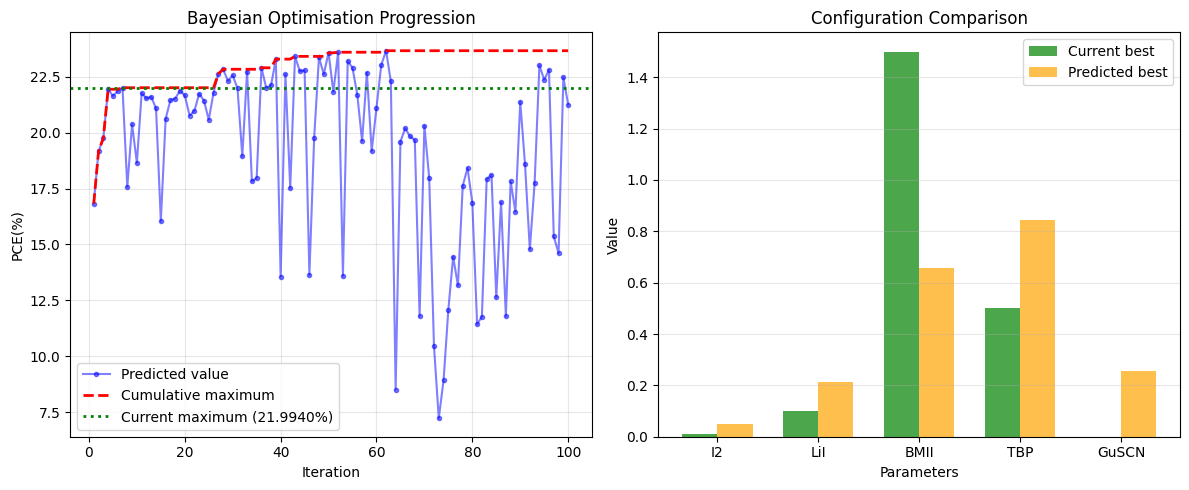

✓ Figures saved to: ./bayesian_optimisation_results_pce.png


In [71]:
# Visualisation of the optimisation progression
if proposed_combinations:
    plt.figure(figsize=(12, 5))

    # Subplot 1: Evolution of the maximum found
    plt.subplot(1, 2, 1)
    max_values = [optimizer.res[i]['target'] for i in range(len(X), len(optimizer.res))]
    cummax_values = np.maximum.accumulate(max_values)
    plt.plot(range(1, len(max_values) + 1), max_values, 'bo-', alpha=0.5, markersize=3, label='Predicted value')
    plt.plot(range(1, len(max_values) + 1), cummax_values, 'r--', linewidth=2, label='Cumulative maximum')
    plt.axhline(y=current_max, color='g', linestyle=':', linewidth=2, label=f'Current maximum ({current_max:.4f}%)')
    plt.xlabel('Iteration')
    plt.ylabel('PCE(%)')
    plt.title('Bayesian Optimisation Progression')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Subplot 2: Parameter comparison
    plt.subplot(1, 2, 2)
    param_names = ['I2', 'LiI', 'BMII', 'TBP', 'GuSCN']
    best_config = proposed_combinations[0]  # Best configuration found
    current_best_params = X[max_idx]

    x_pos = np.arange(len(param_names))
    width = 0.35

    plt.bar(x_pos - width/2, current_best_params, width, label='Current best', alpha=0.7, color='green')
    plt.bar(x_pos + width/2, [best_config[p] for p in param_names], width, label='Predicted best', alpha=0.7, color='orange')
    plt.xlabel('Parameters')
    plt.ylabel('Value')
    plt.title('Configuration Comparison')
    plt.xticks(x_pos, param_names)
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    #plt.savefig('./bayesian_optimisation_results.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("✓ Figures saved to: ./bayesian_optimisation_results_pce.png")
else:
    print("⚠ No figures generated as no configurations improve upon the current maximum.")

## 3. Bayesian Optimisation — $V_{oc}$

The same procedure is repeated, this time targeting the **open-circuit voltage ($V_{oc}$)**. A new Gaussian Process surrogate is fitted to the $V_{oc}$ measurements, and the optimiser searches for electrolyte compositions predicted to yield voltages higher than the current experimental maximum.

In [72]:
df = pd.read_csv('./data-bo-dssc.tsv', sep='\t', decimal=',')
X = df[['I2', 'LiI', 'BMII', 'TBP', 'GuSCN']].values
y = df['Voc(V)'].values

In [73]:
bounds = {'I2': (0, 0.05),
'LiI': (0, 0.5),
'BMII': (0, 1.5),
'TBP': (0, 2),
'GuSCN': (0, 0.5)}

In [74]:
# Verify the current maximum value of Voc
current_max = y.max()
print(f"Current maximum value of Voc(V): {current_max:.4f}")
print(f"Configuration with maximum Voc:")
max_idx = y.argmax()
for i, param in enumerate(['I2', 'LiI', 'BMII', 'TBP', 'GuSCN']):
    print(f"  {param}: {X[max_idx, i]:.4f}")

Current maximum value of Voc(V): 0.7170
Configuration with maximum Voc:
  I2: 0.0250
  LiI: 0.0000
  BMII: 0.5000
  TBP: 1.5000
  GuSCN: 0.0000


In [75]:
# Define the objective function for Bayesian optimisation
def black_box_function(I2, LiI, BMII, TBP, GuSCN):
    """
    Function that the optimiser will attempt to maximise.
    Employs a Gaussian Process fitted to the existing data.
    """
    # Create the point to be evaluated
    x_test = np.array([[I2, LiI, BMII, TBP, GuSCN]])
    
    # Fit the GP using all available data
    kernel = ConstantKernel(1.0) * Matern(length_scale=1.0, nu=2.5)
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)
    gp.fit(X, y)
    
    # Predict the value
    y_pred, sigma = gp.predict(x_test, return_std=True)
    
    return y_pred[0]

In [76]:
# Initialise the Bayesian optimiser
optimizer = BayesianOptimization(
    f=black_box_function,
    pbounds=bounds,
    random_state=42,
    verbose=2
)

# Register the existing data as initial observations
for i in range(len(X)):
    optimizer.register(
        params={
            'I2': X[i, 0],
            'LiI': X[i, 1],
            'BMII': X[i, 2],
            'TBP': X[i, 3],
            'GuSCN': X[i, 4]
        },
        target=y[i]
    )

print(f"\nInitial data registered: {len(X)} experiments")

| 1         | 0.6435    | 0.01      | 0.1       | 1.5       | 1.5       | 0.1       |
| 2         | 0.657     | 0.01      | 0.1       | 0.5       | 1.0       | 0.1       |
| 3         | 0.639     | 0.025     | 0.0       | 1.5       | 0.5       | 0.2       |
| 4         | 0.654     | 0.04      | 0.1       | 0.5       | 1.5       | 0.1       |
| 5         | 0.626     | 0.04      | 0.3       | 1.5       | 1.5       | 0.0       |
| 6         | 0.6565    | 0.025     | 0.0       | 1.5       | 1.5       | 0.0       |
| 7         | 0.6745    | 0.025     | 0.0       | 1.0       | 1.5       | 0.0       |
| 8         | 0.673     | 0.025     | 0.0       | 1.0       | 1.5       | 0.2       |
| 9         | 0.62      | 0.01      | 0.1       | 1.5       | 0.5       | 0.0       |
| 10        | 0.621     | 0.04      | 0.1       | 1.5       | 1.5       | 0.0       |
| 11        | 0.63      | 0.04      | 0.0       | 1.5       | 0.5       | 0.2       |
| 12        | 0.6655    | 0.04      | 0.0       | 0.5 

In [77]:
# Run Bayesian optimisation iterations to identify novel candidate configurations
optimizer.maximize(
    init_points=0,  # Initial observations already registered
    n_iter=100,       # 100 new candidate configurations
)

|   iter    |  target   |    I2     |    LiI    |   BMII    |    TBP    |   GuSCN   |
-------------------------------------------------------------------------------------
| 26        | 0.7305853 | 0.0       | 0.0       | 0.5264377 | 1.4937402 | 0.0       |
| 27        | 0.7321280 | 0.0       | 0.0       | 0.5445152 | 1.5384820 | 0.0       |
| 28        | 0.7065039 | 0.0304731 | 0.0       | 0.5906645 | 1.4979783 | 0.0       |
| 29        | 0.7390227 | 0.0       | 0.0       | 0.5420933 | 1.5241357 | 0.0596563 |
| 30        | 0.7444507 | 0.0       | 0.0       | 0.5630304 | 1.6083718 | 0.0842605 |
| 31        | 0.7444819 | 0.0       | 0.0       | 0.6318000 | 1.5786990 | 0.1534503 |
| 32        | 0.7646389 | 0.0       | 0.0       | 0.5651960 | 1.6605163 | 0.2171061 |
| 33        | 0.6506542 | 0.0125045 | 0.1611063 | 0.8505645 | 0.8331536 | 0.1236240 |
| 34        | 0.5117497 | 0.0361397 | 0.3479348 | 0.4651889 | 1.4219365 | 0.0739343 |
| 35        | 0.6432770 | 0.0130391 | 0.1931077 | 0.76

In [78]:
# Extract proposed configurations that surpass the current maximum
print("\n" + "="*80)
print("PROPOSED CONFIGURATIONS FOR IMPROVING Voc")
print("="*80)
current_max = y.max()
print(f"Current maximum in the dataset: {current_max:.4f} V")
print("="*80)

proposed_combinations = []

# Retrieve only the last 100 iterations (the new proposals)
all_iterations = len(optimizer.res)
start_idx = len(X)  # Start after the original data

# Filter only the configurations that surpass the current maximum
for res in optimizer.res[start_idx:]:
    params = res['params']
    target = res['target']
    
    # Only include if the predicted Voc exceeds the current maximum
    if target > current_max:
        combination = {
            'I2': params['I2'],
            'LiI': params['LiI'],
            'BMII': params['BMII'],
            'TBP': params['TBP'],
            'GuSCN': params['GuSCN'],
            'Voc_predicted(V)': target,
            'Improvement(V)': target - current_max
        }
        proposed_combinations.append(combination)

# Sort by predicted Voc (descending) and retain the top results
proposed_combinations = sorted(proposed_combinations, key=lambda x: x['Voc_predicted(V)'], reverse=True)

if proposed_combinations:
    print(f"\n{len(proposed_combinations)} configurations found that surpass the current maximum:\n")
    for idx, combination in enumerate(proposed_combinations, 1):
        print(f"Experiment {idx}:")
        print(f"  I2:     {combination['I2']:.4f}")
        print(f"  LiI:    {combination['LiI']:.4f}")
        print(f"  BMII:   {combination['BMII']:.4f}")
        print(f"  TBP:    {combination['TBP']:.4f}")
        print(f"  GuSCN:  {combination['GuSCN']:.4f}")
        print(f"  Predicted Voc: {combination['Voc_predicted(V)']:.4f} V")
        print(f"  Improvement: +{combination['Improvement(V)']:.4f} V\n")
    
    print("="*80)
    print(f"Best result found: {proposed_combinations[0]['Voc_predicted(V)']:.4f} V")
    print(f"Improvement over current maximum: +{proposed_combinations[0]['Improvement(V)']:.4f} V")
    print("="*80)
else:
    print("\n⚠ No configurations found that surpass the current maximum.")
    print("This may indicate that the model regards the current maximum as already optimal.")
    print("="*80)


PROPOSED CONFIGURATIONS FOR IMPROVING Voc
Current maximum in the dataset: 0.7170 V

89 configurations found that surpass the current maximum:

Experiment 1:
  I2:     0.0000
  LiI:    0.0000
  BMII:   0.2537
  TBP:    1.6065
  GuSCN:  0.5000
  Predicted Voc: 0.8308 V
  Improvement: +0.1138 V

Experiment 2:
  I2:     0.0000
  LiI:    0.0000
  BMII:   0.2571
  TBP:    1.6082
  GuSCN:  0.5000
  Predicted Voc: 0.8308 V
  Improvement: +0.1138 V

Experiment 3:
  I2:     0.0000
  LiI:    0.0000
  BMII:   0.2529
  TBP:    1.6178
  GuSCN:  0.5000
  Predicted Voc: 0.8308 V
  Improvement: +0.1138 V

Experiment 4:
  I2:     0.0000
  LiI:    0.0000
  BMII:   0.2578
  TBP:    1.6145
  GuSCN:  0.5000
  Predicted Voc: 0.8308 V
  Improvement: +0.1138 V

Experiment 5:
  I2:     0.0000
  LiI:    0.0000
  BMII:   0.2527
  TBP:    1.6181
  GuSCN:  0.5000
  Predicted Voc: 0.8308 V
  Improvement: +0.1138 V

Experiment 6:
  I2:     0.0000
  LiI:    0.0000
  BMII:   0.2587
  TBP:    1.6123
  GuSCN:  0.5000
  

In [79]:
# Create a DataFrame from the proposals only if there are configurations that improve upon the current maximum
if proposed_combinations:
    df_proposed = pd.DataFrame(proposed_combinations)
    # Add experiment number
    df_proposed.insert(0, 'Experiment', range(1, len(proposed_combinations) + 1))
    
    print("\nTable of proposed experiments (only those that surpass the current maximum):")
    print(df_proposed.to_string(index=False))
    
    # Save the proposals to a CSV file
    output_file = './proposed_bo_experiments_voc.csv'
    df_proposed.to_csv(output_file, index=False)
    print(f"\n✓ {len(proposed_combinations)} proposals saved to: {output_file}")
else:
    print("\n⚠ No experiments surpass the current maximum; nothing to save.")


Table of proposed experiments (only those that surpass the current maximum):
 Experiment   I2  LiI     BMII      TBP    GuSCN  Voc_predicted(V)  Improvement(V)
          1 0.00  0.0 0.253738 1.606453 0.500000          0.830771        0.113771
          2 0.00  0.0 0.257089 1.608154 0.500000          0.830771        0.113771
          3 0.00  0.0 0.252915 1.617751 0.500000          0.830771        0.113771
          4 0.00  0.0 0.257838 1.614535 0.500000          0.830771        0.113771
          5 0.00  0.0 0.252720 1.618113 0.500000          0.830770        0.113770
          6 0.00  0.0 0.258749 1.612269 0.500000          0.830770        0.113770
          7 0.00  0.0 0.258790 1.611820 0.500000          0.830770        0.113770
          8 0.00  0.0 0.253910 1.605678 0.500000          0.830769        0.113769
          9 0.00  0.0 0.247329 1.611630 0.500000          0.830768        0.113768
         10 0.00  0.0 0.259096 1.612319 0.500000          0.830768        0.113768
         

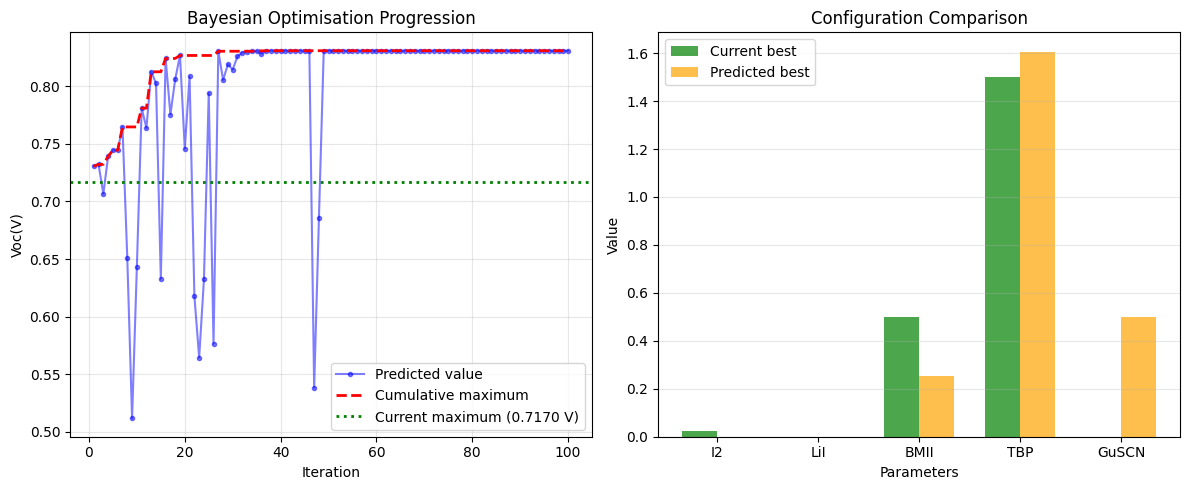

✓ Figures saved to: ./bayesian_optimisation_results_voc.png


In [80]:
# Visualisation of the optimisation progression
if proposed_combinations:
    plt.figure(figsize=(12, 5))

    # Subplot 1: Evolution of the maximum found
    plt.subplot(1, 2, 1)
    max_values = [optimizer.res[i]['target'] for i in range(len(X), len(optimizer.res))]
    cummax_values = np.maximum.accumulate(max_values)
    plt.plot(range(1, len(max_values) + 1), max_values, 'bo-', alpha=0.5, markersize=3, label='Predicted value')
    plt.plot(range(1, len(max_values) + 1), cummax_values, 'r--', linewidth=2, label='Cumulative maximum')
    plt.axhline(y=current_max, color='g', linestyle=':', linewidth=2, label=f'Current maximum ({current_max:.4f} V)')
    plt.xlabel('Iteration')
    plt.ylabel('Voc(V)')
    plt.title('Bayesian Optimisation Progression')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Subplot 2: Parameter comparison
    plt.subplot(1, 2, 2)
    param_names = ['I2', 'LiI', 'BMII', 'TBP', 'GuSCN']
    best_config = proposed_combinations[0]  # Best configuration found
    current_best_params = X[max_idx]

    x_pos = np.arange(len(param_names))
    width = 0.35

    plt.bar(x_pos - width/2, current_best_params, width, label='Current best', alpha=0.7, color='green')
    plt.bar(x_pos + width/2, [best_config[p] for p in param_names], width, label='Predicted best', alpha=0.7, color='orange')
    plt.xlabel('Parameters')
    plt.ylabel('Value')
    plt.title('Configuration Comparison')
    plt.xticks(x_pos, param_names)
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    #plt.savefig('./bayesian_optimisation_results_voc.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("✓ Figures saved to: ./bayesian_optimisation_results_voc.png")
else:
    print("⚠ No figures generated as no configurations improve upon the current maximum.")

## 4. Bayesian Optimisation — $J_{sc}$

Finally, the optimisation is repeated for the **short-circuit current density ($J_{sc}$)**. This completes the three-target analysis, giving a set of candidate compositions that may independently improve each performance metric.

In [81]:
df = pd.read_csv('./data-bo-dssc.tsv', sep='\t', decimal=',')
X = df[['I2', 'LiI', 'BMII', 'TBP', 'GuSCN']].values
y = df['Jsc(uAcm-2)'].values

In [82]:
bounds = {'I2': (0, 0.05),
'LiI': (0, 0.5),
'BMII': (0, 1.5),
'TBP': (0, 2),
'GuSCN': (0, 0.5)}

In [83]:
# Verify the current maximum value of Jsc
current_max = y.max()
print(f"Current maximum value of Jsc(uAcm-2): {current_max:.4f}")
print(f"Configuration with maximum Jsc(uAcm-2):")
max_idx = y.argmax()
for i, param in enumerate(['I2', 'LiI', 'BMII', 'TBP', 'GuSCN']):
    print(f"  {param}: {X[max_idx, i]:.4f}")

Current maximum value of Jsc(uAcm-2): 64.7656
Configuration with maximum Jsc(uAcm-2):
  I2: 0.0100
  LiI: 0.1000
  BMII: 1.5000
  TBP: 0.5000
  GuSCN: 0.0000


In [84]:
# Define the objective function for Bayesian optimisation
def black_box_function(I2, LiI, BMII, TBP, GuSCN):
    """
    Function that the optimiser will attempt to maximise.
    Employs a Gaussian Process fitted to the existing data.
    """
    # Create the point to be evaluated
    x_test = np.array([[I2, LiI, BMII, TBP, GuSCN]])
    
    # Fit the GP using all available data
    kernel = ConstantKernel(1.0) * Matern(length_scale=1.0, nu=2.5)
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)
    gp.fit(X, y)
    
    # Predict the value
    y_pred, sigma = gp.predict(x_test, return_std=True)
    
    return y_pred[0]

In [85]:
# Initialise the Bayesian optimiser
optimizer = BayesianOptimization(
    f=black_box_function,
    pbounds=bounds,
    random_state=42,
    verbose=2
)

# Register the existing data as initial observations
for i in range(len(X)):
    optimizer.register(
        params={
            'I2': X[i, 0],
            'LiI': X[i, 1],
            'BMII': X[i, 2],
            'TBP': X[i, 3],
            'GuSCN': X[i, 4]
        },
        target=y[i]
    )

print(f"\nInitial data registered: {len(X)} experiments")

| 1         | 59.385437 | 0.01      | 0.1       | 1.5       | 1.5       | 0.1       |
| 2         | 59.937375 | 0.01      | 0.1       | 0.5       | 1.0       | 0.1       |
| 3         | 52.663593 | 0.025     | 0.0       | 1.5       | 0.5       | 0.2       |
| 4         | 56.522968 | 0.04      | 0.1       | 0.5       | 1.5       | 0.1       |
| 5         | 61.310468 | 0.04      | 0.3       | 1.5       | 1.5       | 0.0       |
| 6         | 40.081562 | 0.025     | 0.0       | 1.5       | 1.5       | 0.0       |
| 7         | 37.187937 | 0.025     | 0.0       | 1.0       | 1.5       | 0.0       |
| 8         | 42.301812 | 0.025     | 0.0       | 1.0       | 1.5       | 0.2       |
| 9         | 64.765625 | 0.01      | 0.1       | 1.5       | 0.5       | 0.0       |
| 10        | 56.010093 | 0.04      | 0.1       | 1.5       | 1.5       | 0.0       |
| 11        | 55.204687 | 0.04      | 0.0       | 1.5       | 0.5       | 0.2       |
| 12        | 54.580281 | 0.04      | 0.0       | 0.5 

In [86]:
# Run Bayesian optimisation iterations to identify novel candidate configurations
optimizer.maximize(
    init_points=0,  # Initial observations already registered
    n_iter=100,       # 100 new candidate configurations
)

|   iter    |  target   |    I2     |    LiI    |   BMII    |    TBP    |   GuSCN   |
-------------------------------------------------------------------------------------
| 26        | 57.406670 | 0.0077997 | 0.4328504 | 1.1078565 | 1.4004200 | 0.1211309 |
| 27        | 60.374159 | 0.0383763 | 0.2859539 | 0.5055601 | 0.5191645 | 0.0799894 |
| 28        | 62.541246 | 0.0453036 | 0.2852972 | 0.5044626 | 0.5284121 | 0.1151044 |
| 29        | 64.716340 | 0.0102597 | 0.1008727 | 1.4999931 | 0.4991770 | 0.0302446 |
| 30        | 64.730937 | 0.0110941 | 0.0978908 | 1.4974024 | 0.5324710 | 0.0159153 |
| 31        | 66.292969 | 0.0097894 | 0.1352128 | 1.4943269 | 0.5150075 | 0.0143377 |
| 32        | 70.729734 | 0.0420499 | 0.1162613 | 1.4757466 | 0.5111180 | 0.0144653 |
| 33        | 58.927101 | 0.0125045 | 0.1611063 | 0.8505645 | 0.8331536 | 0.1236240 |
| 34        | 69.690268 | 0.0361397 | 0.3479348 | 0.4651889 | 1.4219365 | 0.0739343 |
| 35        | 63.462355 | 0.0352965 | 0.2792114 | 0.49

In [87]:
# Extract proposed configurations that surpass the current maximum
print("\n" + "="*80)
print("PROPOSED CONFIGURATIONS FOR IMPROVING Jsc")
print("="*80)
current_max = y.max()
print(f"Current maximum in the dataset: {current_max:.4f} uAcm-2")
print("="*80)

proposed_combinations = []

# Retrieve only the last 100 iterations (the new proposals)
all_iterations = len(optimizer.res)
start_idx = len(X)  # Start after the original data

# Filter only the configurations that surpass the current maximum
for res in optimizer.res[start_idx:]:
    params = res['params']
    target = res['target']
    
    # Only include if the predicted Jsc exceeds the current maximum
    if target > current_max:
        combination = {
            'I2': params['I2'],
            'LiI': params['LiI'],
            'BMII': params['BMII'],
            'TBP': params['TBP'],
            'GuSCN': params['GuSCN'],
            'Jsc_predicted(uAcm-2)': target,
            'Improvement(uAcm-2)': target - current_max
        }
        proposed_combinations.append(combination)

# Sort by predicted Jsc (descending) and retain the top results
proposed_combinations = sorted(proposed_combinations, key=lambda x: x['Jsc_predicted(uAcm-2)'], reverse=True)

if proposed_combinations:
    print(f"\n{len(proposed_combinations)} configurations found that surpass the current maximum:\n")
    for idx, combination in enumerate(proposed_combinations, 1):
        print(f"Experiment {idx}:")
        print(f"  I2:     {combination['I2']:.4f}")
        print(f"  LiI:    {combination['LiI']:.4f}")
        print(f"  BMII:   {combination['BMII']:.4f}")
        print(f"  TBP:    {combination['TBP']:.4f}")
        print(f"  GuSCN:  {combination['GuSCN']:.4f}")
        print(f"  Predicted Jsc: {combination['Jsc_predicted(uAcm-2)']:.4f} uAcm-2")
        print(f"  Improvement: +{combination['Improvement(uAcm-2)']:.4f} uAcm-2\n")
    
    print("="*80)
    print(f"Best result found: {proposed_combinations[0]['Jsc_predicted(uAcm-2)']:.4f} uAcm-2")
    print(f"Improvement over current maximum: +{proposed_combinations[0]['Improvement(uAcm-2)']:.4f} uAcm-2")
    print("="*80)
else:
    print("\n⚠ No configurations found that surpass the current maximum.")
    print("This may indicate that the model regards the current maximum as already optimal.")
    print("="*80)


PROPOSED CONFIGURATIONS FOR IMPROVING Jsc
Current maximum in the dataset: 64.7656 uAcm-2

72 configurations found that surpass the current maximum:

Experiment 1:
  I2:     0.0500
  LiI:    0.1788
  BMII:   1.4116
  TBP:    1.5087
  GuSCN:  0.3713
  Predicted Jsc: 83.6705 uAcm-2
  Improvement: +18.9049 uAcm-2

Experiment 2:
  I2:     0.0500
  LiI:    0.2975
  BMII:   1.5000
  TBP:    1.4294
  GuSCN:  0.4446
  Predicted Jsc: 82.3108 uAcm-2
  Improvement: +17.5452 uAcm-2

Experiment 3:
  I2:     0.0500
  LiI:    0.2608
  BMII:   1.3062
  TBP:    1.4981
  GuSCN:  0.3690
  Predicted Jsc: 82.2163 uAcm-2
  Improvement: +17.4507 uAcm-2

Experiment 4:
  I2:     0.0500
  LiI:    0.2658
  BMII:   1.5000
  TBP:    1.6099
  GuSCN:  0.3404
  Predicted Jsc: 81.9944 uAcm-2
  Improvement: +17.2287 uAcm-2

Experiment 5:
  I2:     0.0500
  LiI:    0.1402
  BMII:   1.5000
  TBP:    1.3595
  GuSCN:  0.4453
  Predicted Jsc: 80.1758 uAcm-2
  Improvement: +15.4102 uAcm-2

Experiment 6:
  I2:     0.0500
  Li

In [88]:
# Create a DataFrame from the proposals only if there are configurations that improve upon the current maximum
if proposed_combinations:
    df_proposed = pd.DataFrame(proposed_combinations)
    # Add experiment number
    df_proposed.insert(0, 'Experiment', range(1, len(proposed_combinations) + 1))
    
    print("\nTable of proposed experiments (only those that surpass the current maximum):")
    print(df_proposed.to_string(index=False))
    
    # Save the proposals to a CSV file
    output_file = './proposed_bo_experiments_jsc.csv'
    df_proposed.to_csv(output_file, index=False)
    print(f"\n✓ {len(proposed_combinations)} proposals saved to: {output_file}")
else:
    print("\n⚠ No experiments surpass the current maximum; nothing to save.")


Table of proposed experiments (only those that surpass the current maximum):
 Experiment       I2      LiI     BMII      TBP    GuSCN  Jsc_predicted(uAcm-2)  Improvement(uAcm-2)
          1 0.050000 0.178816 1.411586 1.508653 0.371346              83.670548            18.904923
          2 0.050000 0.297498 1.500000 1.429354 0.444582              82.310776            17.545151
          3 0.050000 0.260795 1.306204 1.498128 0.368991              82.216330            17.450705
          4 0.050000 0.265809 1.500000 1.609867 0.340390              81.994357            17.228732
          5 0.050000 0.140229 1.500000 1.359491 0.445343              80.175786            15.410161
          6 0.050000 0.236773 1.375712 1.384965 0.500000              79.292036            14.526411
          7 0.050000 0.325693 1.500000 1.286429 0.454429              78.742366            13.976741
          8 0.050000 0.169724 1.500000 1.546713 0.500000              78.415586            13.649961
          9 0

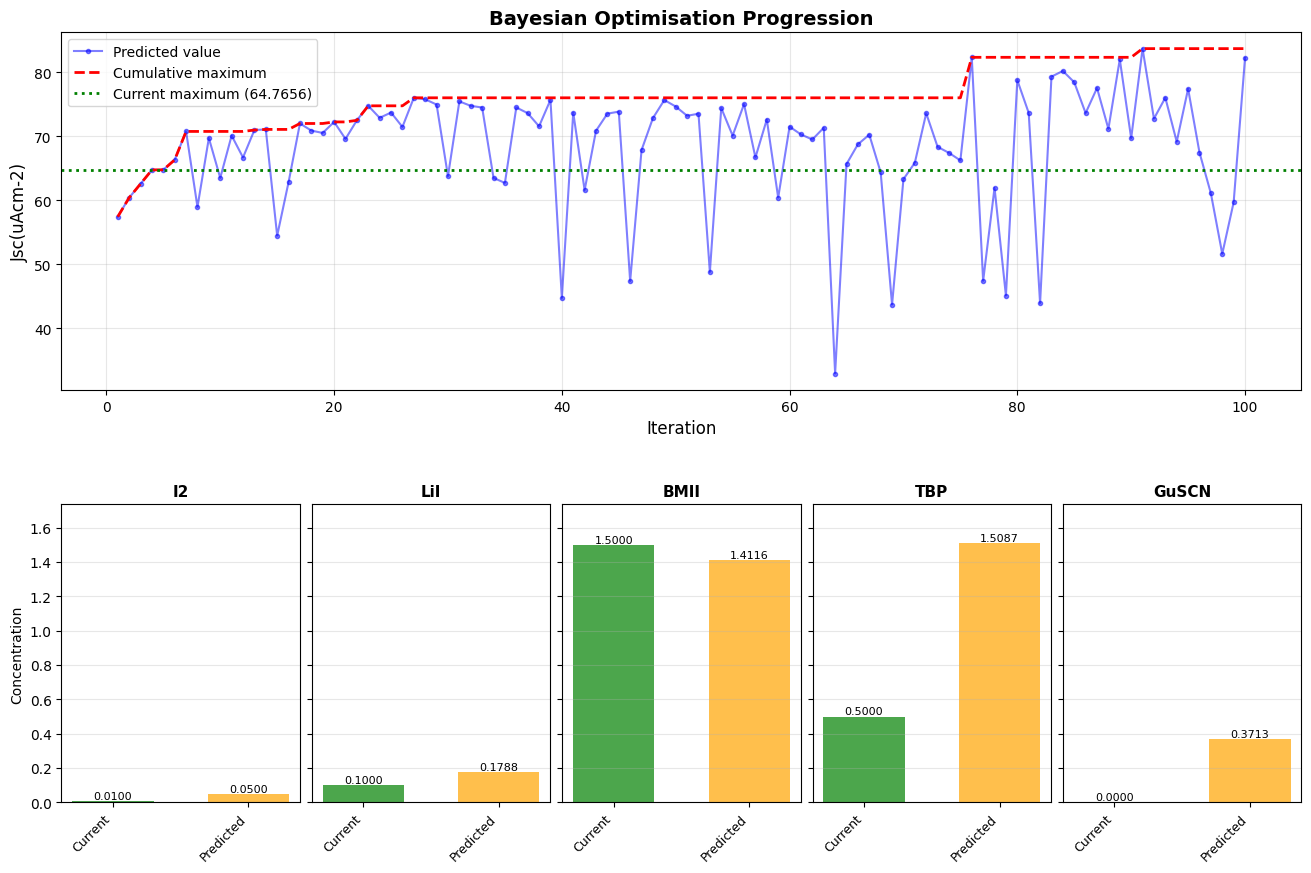

✓ Figures saved to: ./bayesian_optimisation_results_jsc.png


In [89]:
# Visualisation of the optimisation progression
if proposed_combinations:
    fig = plt.figure(figsize=(16, 10))
    
    # Create grid: top row for progression, bottom row for 5 individual parameters sharing the y-axis
    gs = fig.add_gridspec(2, 5, height_ratios=[1.2, 1], hspace=0.35, wspace=0.05)
    
    # Upper subplot: Evolution of the maximum found (spans the entire top row)
    ax_evolution = fig.add_subplot(gs[0, :])
    max_values = [optimizer.res[i]['target'] for i in range(len(X), len(optimizer.res))]
    cummax_values = np.maximum.accumulate(max_values)
    ax_evolution.plot(range(1, len(max_values) + 1), max_values, 'bo-', alpha=0.5, markersize=3, label='Predicted value')
    ax_evolution.plot(range(1, len(max_values) + 1), cummax_values, 'r--', linewidth=2, label='Cumulative maximum')
    ax_evolution.axhline(y=current_max, color='g', linestyle=':', linewidth=2, label=f'Current maximum ({current_max:.4f})')
    ax_evolution.set_xlabel('Iteration', fontsize=12)
    ax_evolution.set_ylabel('Jsc(uAcm-2)', fontsize=12)
    ax_evolution.set_title('Bayesian Optimisation Progression', fontsize=14, fontweight='bold')
    ax_evolution.legend(fontsize=10)
    ax_evolution.grid(True, alpha=0.3)

    # Lower subplots: Individual comparison of each parameter (5 plots sharing the y-axis)
    param_names = ['I2', 'LiI', 'BMII', 'TBP', 'GuSCN']
    best_config = proposed_combinations[0]  # Best configuration found
    current_best_params = X[max_idx]
    
    # Determine the shared y-axis range
    all_values = []
    for i, param in enumerate(param_names):
        all_values.extend([current_best_params[i], best_config[param]])
    y_max = max(all_values) * 1.15  # 15% upper margin
    
    for i, param in enumerate(param_names):
        if i == 0:
            ax = fig.add_subplot(gs[1, i])
            ax_first = ax
        else:
            ax = fig.add_subplot(gs[1, i], sharey=ax_first)
        
        x_pos = np.array([0, 1])
        values = [current_best_params[i], best_config[param]]
        colors = ['green', 'orange']
        
        bars = ax.bar(x_pos, values, color=colors, alpha=0.7, width=0.6)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(['Current', 'Predicted'], fontsize=9, rotation=45, ha='right')
        ax.set_title(f'{param}', fontsize=11, fontweight='bold')
        ax.set_ylim(0, y_max)
        ax.grid(True, alpha=0.3, axis='y')
        
        # Only show the y-axis label on the first subplot
        if i == 0:
            ax.set_ylabel('Concentration', fontsize=10)
        else:
            ax.tick_params(labelleft=False)
        
        # Add value annotations above each bar
        for bar, val in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{val:.4f}',
                    ha='center', va='bottom', fontsize=8)

    #plt.savefig('./bayesian_optimisation_results_jsc.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("✓ Figures saved to: ./bayesian_optimisation_results_jsc.png")
else:
    print("⚠ No figures generated as no configurations improve upon the current maximum.")

In [90]:
proposed_pce_data = pd.read_csv('./proposed_bo_experiments_pce.csv')
proposed_voc_data = pd.read_csv('./proposed_bo_experiments_voc.csv')
proposed_jsc_data = pd.read_csv('./proposed_bo_experiments_jsc.csv')


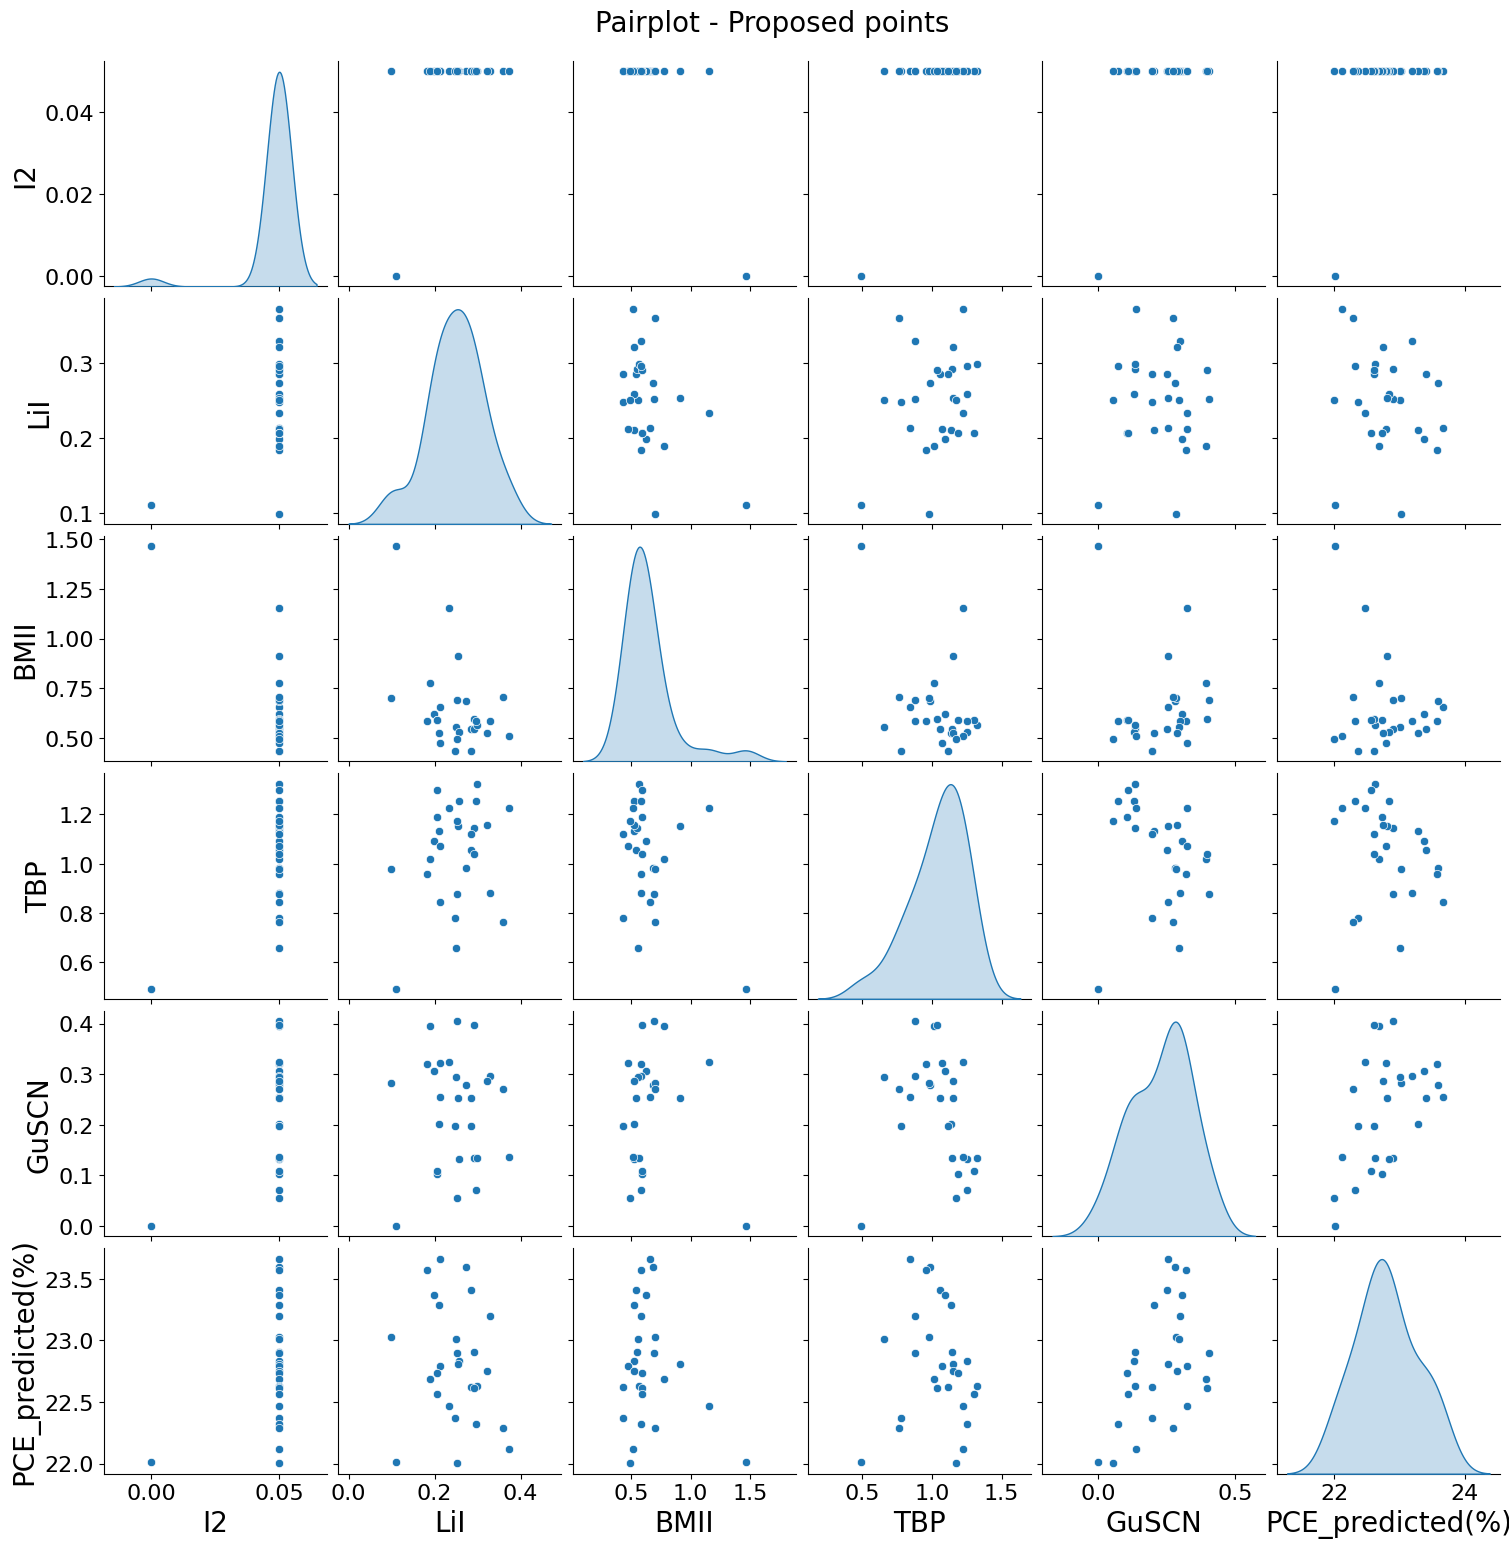

In [91]:

g = sns.pairplot(proposed_pce_data.drop(columns=['Experiment', 'Improvement(%)']), diag_kind='kde')

# Iterate over all subplots to adjust font sizes
for ax in g.axes.flatten():
    if ax:
        # Increase axis label sizes (x and y)
        ax.set_xlabel(ax.get_xlabel(), fontsize=20)
        ax.set_ylabel(ax.get_ylabel(), fontsize=20)
        
        # Increase tick label sizes (numbers on axes)
        ax.tick_params(axis='both', labelsize=16)

g.fig.suptitle('Pairplot - Proposed points', y=1.02, fontsize=20)
plt.show()


<Figure size 1000x1000 with 0 Axes>

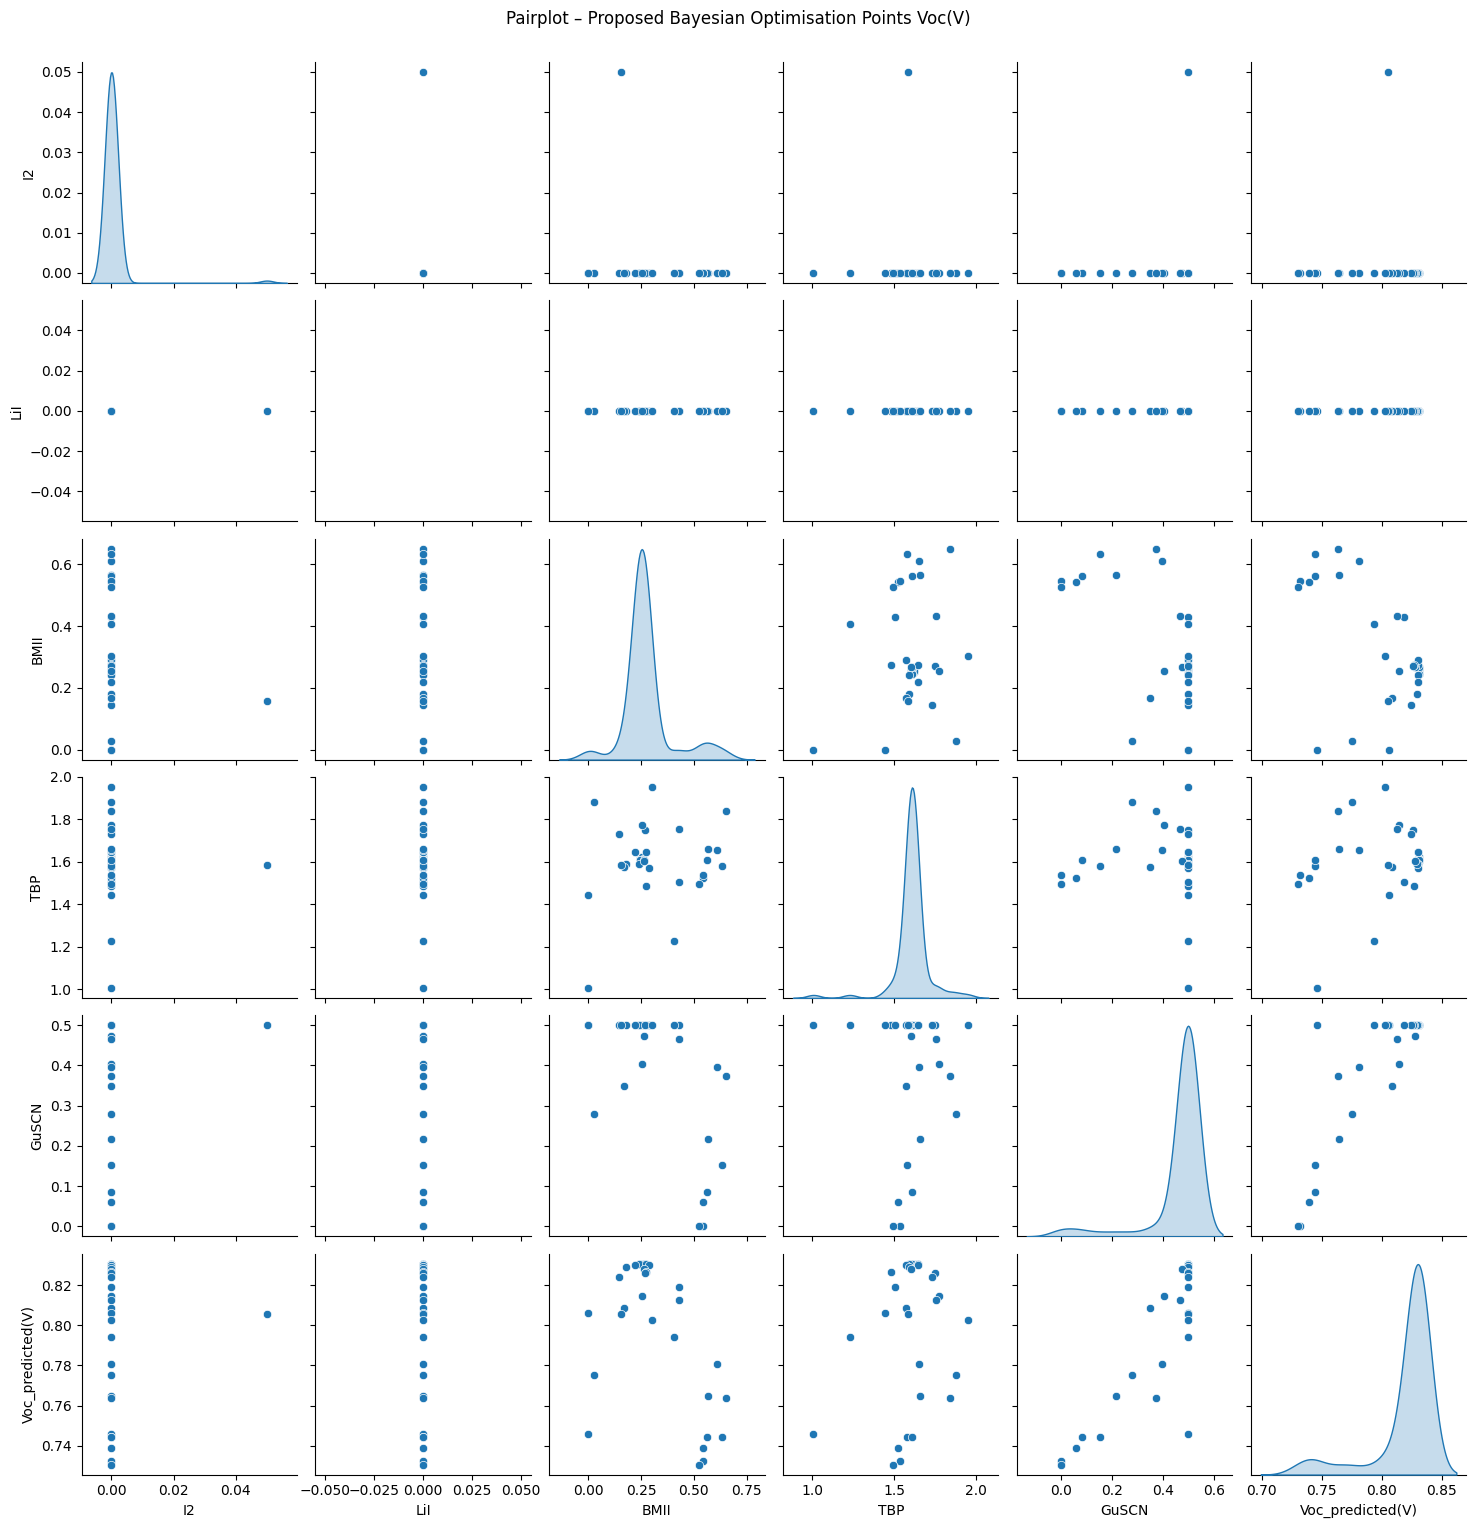

In [92]:
fig=plt.figure(figsize=(10, 10))
sns.pairplot(proposed_voc_data.drop(columns=['Experiment', 'Improvement(V)']), diag_kind='kde')
plt.suptitle('Pairplot – Proposed Bayesian Optimisation Points Voc(V)', y=1.02)
plt.show()

<Figure size 1000x1000 with 0 Axes>

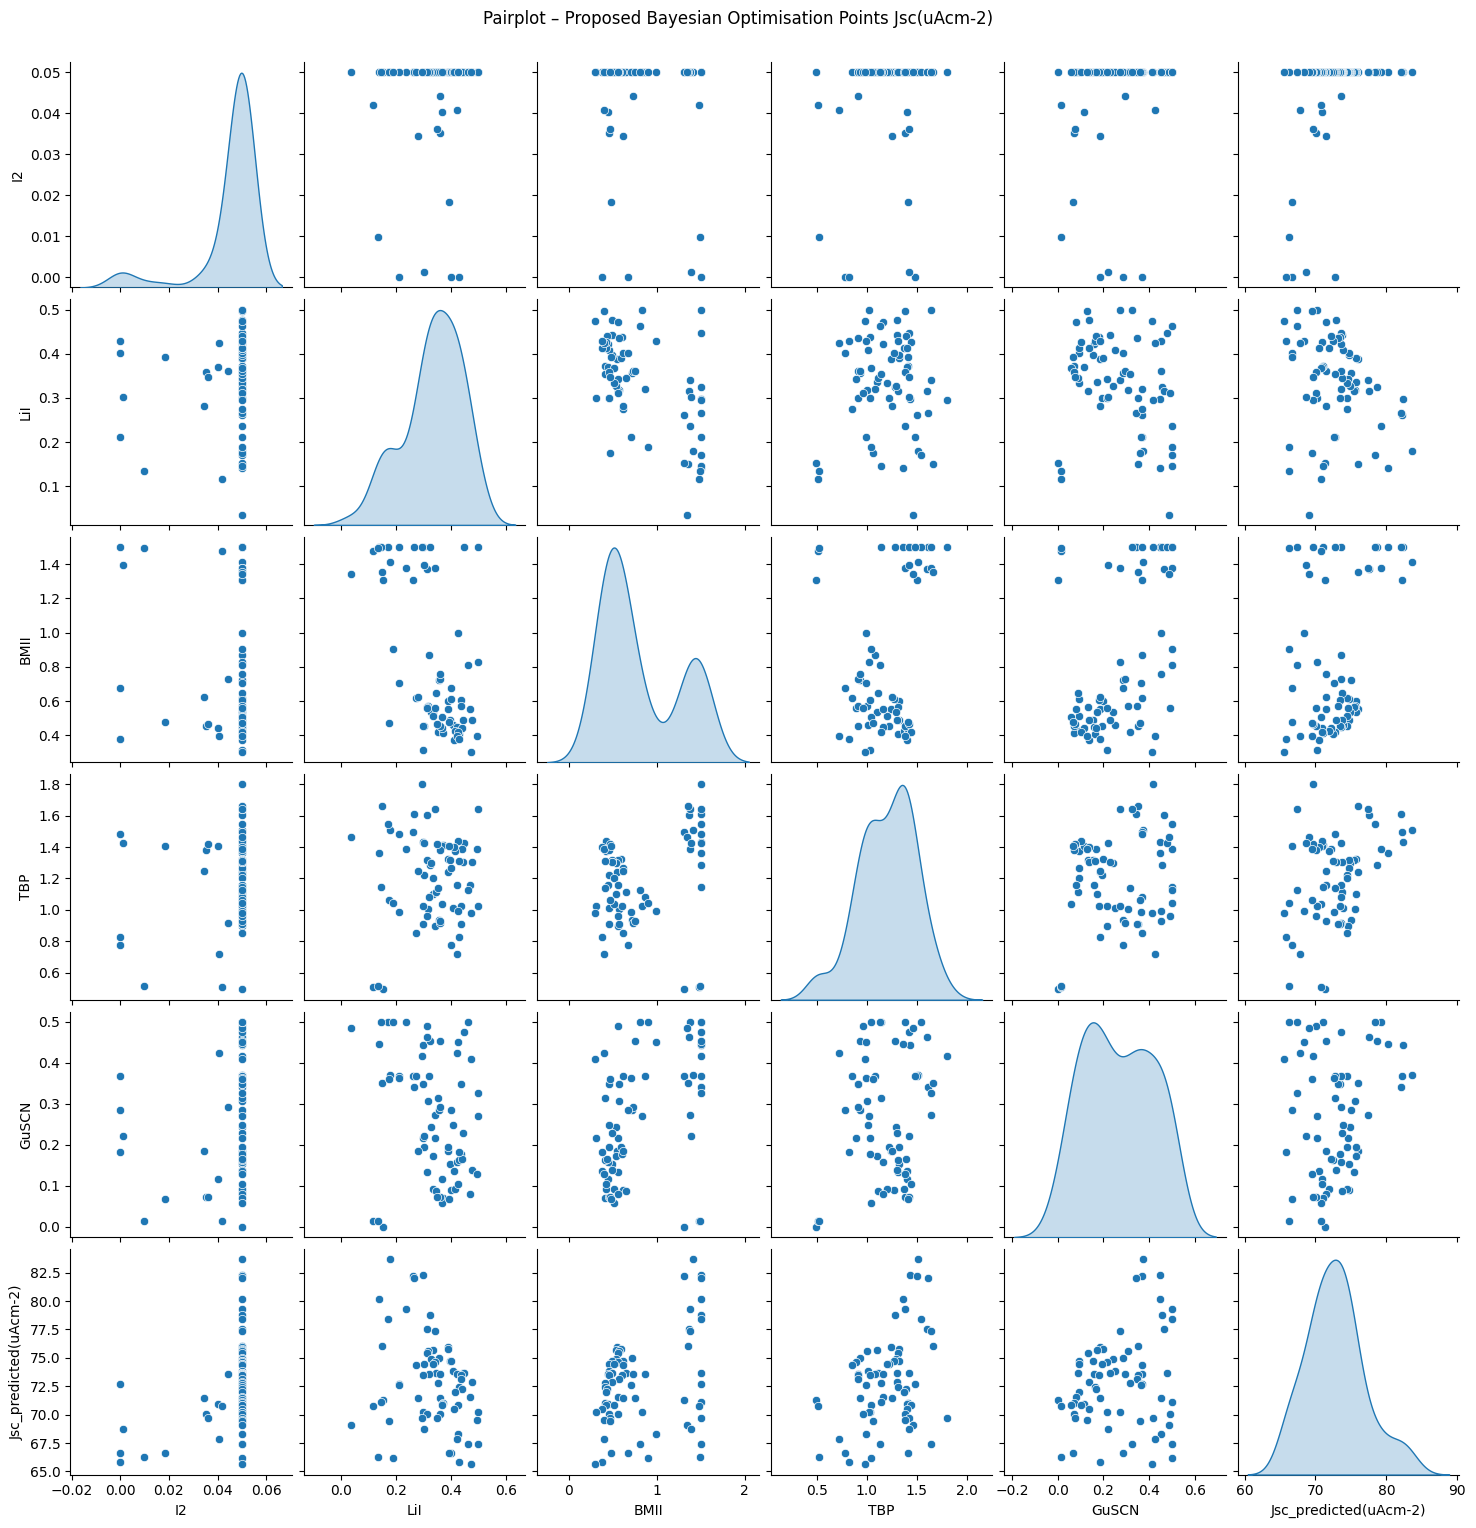

In [93]:
fig=plt.figure(figsize=(10, 10))
sns.pairplot(proposed_jsc_data.drop(columns=['Experiment', 'Improvement(uAcm-2)']), diag_kind='kde')
plt.suptitle('Pairplot – Proposed Bayesian Optimisation Points Jsc(uAcm-2)', y=1.02)
plt.show()

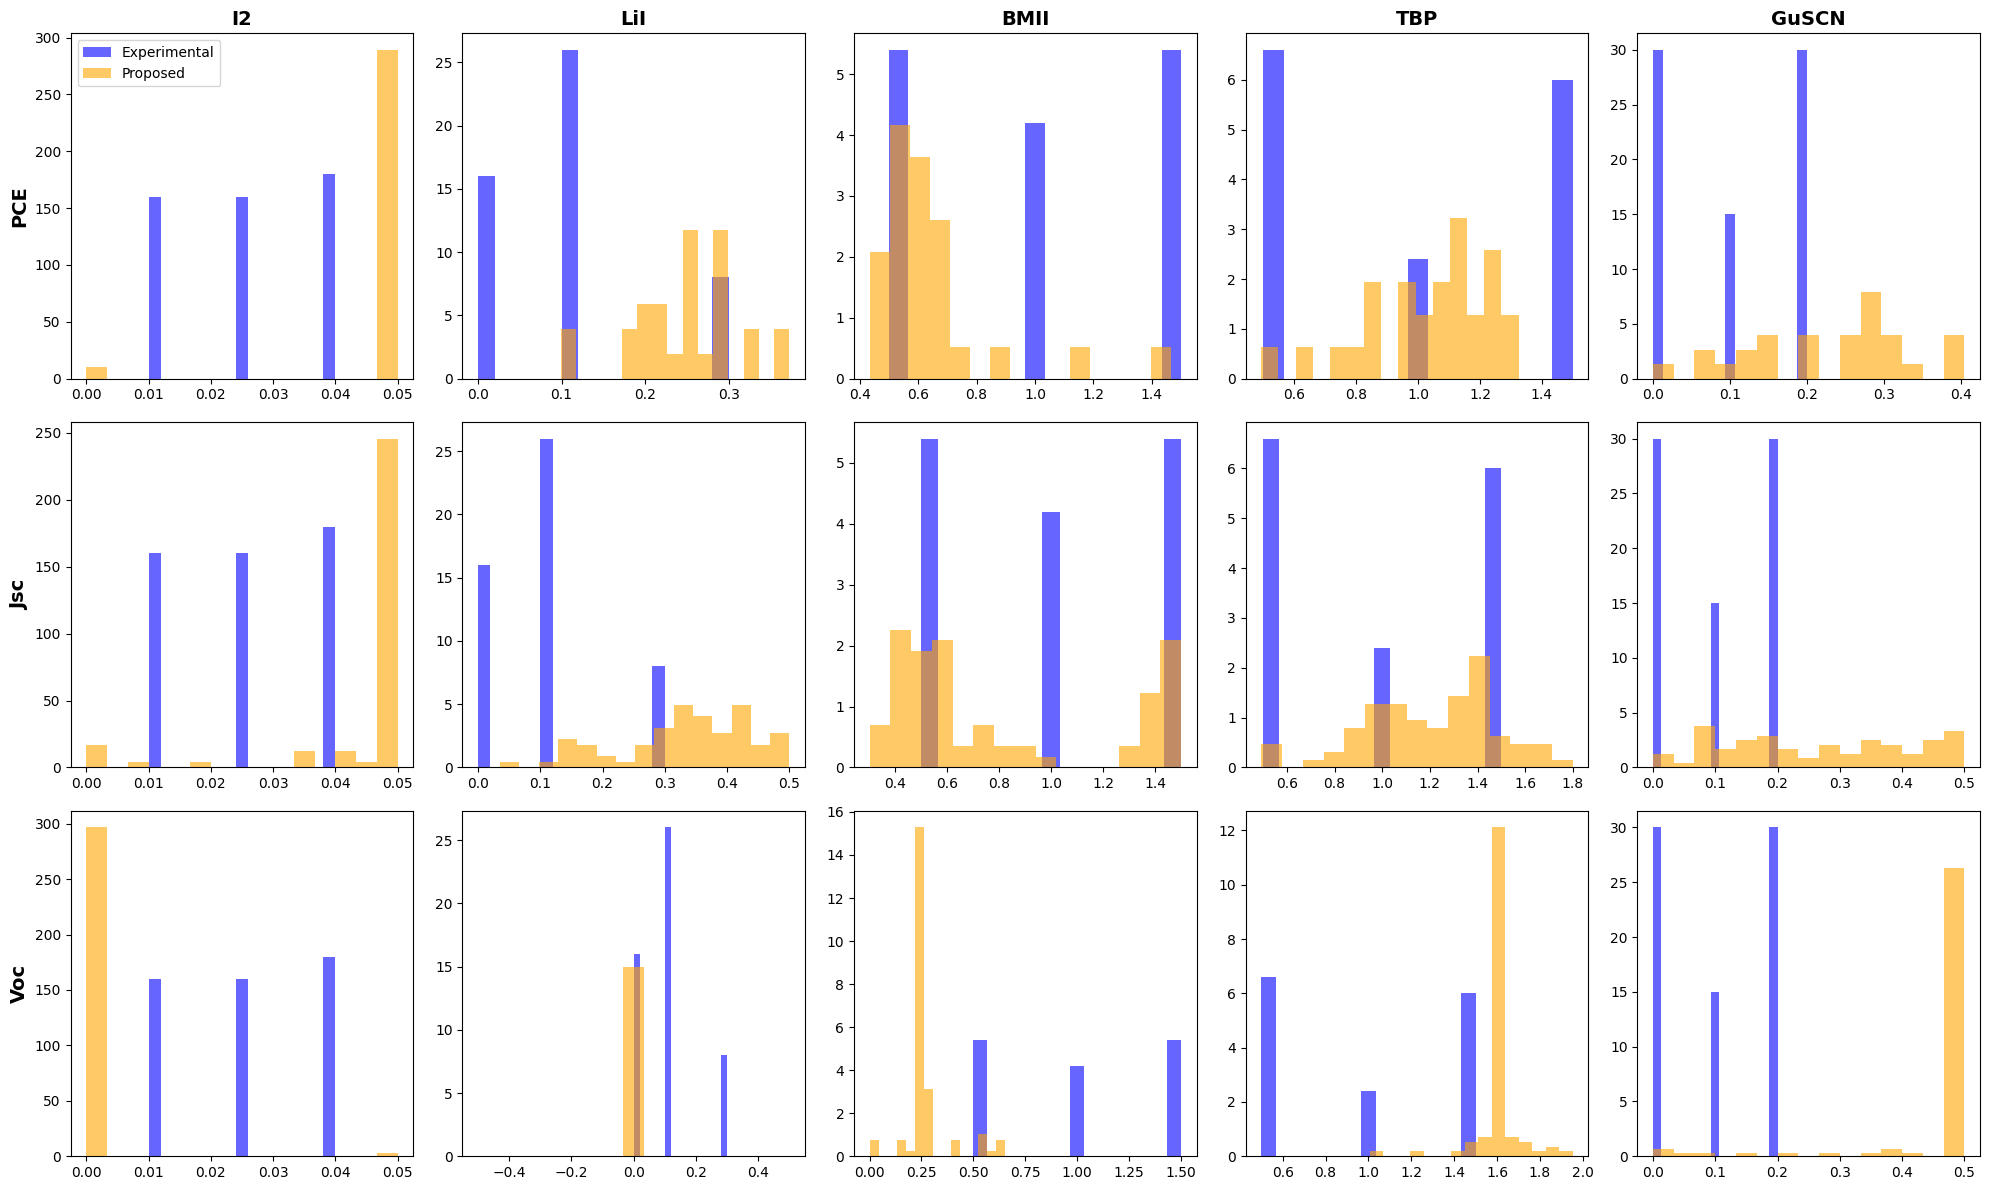

In [96]:
# Load experimental data
df_exp = pd.read_csv('./data-bo-dssc.tsv', sep='\t', decimal=',')

# Load optimisation proposals
df_pce = pd.read_csv('./proposed_bo_experiments_pce.csv')
df_jsc = pd.read_csv('./proposed_bo_experiments_jsc.csv')
df_voc = pd.read_csv('./proposed_bo_experiments_voc.csv')

# Input components and target variables
components = ['I2', 'LiI', 'BMII', 'TBP', 'GuSCN']
targets = ['PCE', 'Jsc', 'Voc']
propuestas = {'PCE': df_pce, 'Jsc': df_jsc, 'Voc': df_voc}

# Create figure: 3 rows × 5 columns
fig, axes = plt.subplots(3, 5, figsize=(20, 12))

for i, target in enumerate(targets):
    for j, comp in enumerate(components):
        ax = axes[i, j]
        
        # Experimental data
        exp_data = df_exp[comp].values
        
        # Proposed data
        prop_data = propuestas[target][comp].values
        
        # Overlaid histograms
        ax.hist(exp_data, bins=15, alpha=0.6, label='Experimental', color='blue', density=True)
        ax.hist(prop_data, bins=15, alpha=0.6, label='Proposed', color='orange', density=True)
        
        # Axis labels
        if i == 0:
            ax.set_title(comp, fontsize=14, fontweight='bold')
        if j == 0:
            ax.set_ylabel(target, fontsize=14, fontweight='bold')
        
        # Legend in the first cell only
        if i == 0 and j == 0:
            ax.legend(fontsize=10)

plt.tight_layout()
#plt.savefig('histograms_experimental_vs_proposed.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Surrogate Model Validation — Leave-One-Out Cross-Validation (LOOCV)

Before trusting the optimiser's recommendations, it is important to assess how well the Gaussian Process surrogate actually predicts experimental outcomes.

**Leave-One-Out Cross-Validation (LOOCV)** provides a rigorous estimate of predictive accuracy without requiring a separate test set — especially valuable when data are scarce. In each fold, one experiment is held out, the GP is re-fitted on the remaining data, and a prediction is made for the held-out point. This is repeated for every experiment, yielding a set of *predicted vs. measured* pairs that quantify the model's generalisation ability.

The same Matérn kernel used during optimisation is employed here, ensuring that the validation reflects the actual surrogate quality.

-76.31492643369053
-77.09952623205304
-78.17305592955292
-78.19923897465561
-77.79165400506221
-75.48624799697009
-77.20580221703696
-78.62053504616888
-109.2268470331936
-77.31727614032108
-78.25132392139344
-78.18614176867857
-77.62802726034107
-77.93306627027803
-73.39582176285681
-77.82188917759935
-78.9712217583552
-77.0986346224298
-78.29833732847759
-78.53914694975607
-77.11277404014149
-79.0369922777186
-78.63962940575068
-78.25981529105907
-77.88788452779642
PCE (%)               R² = 0.1663   MAE = 1.3204
Optimised kernel for PCE (%): 3.16**2 * Matern(length_scale=[5.23, 3.37, 2.72, 4.97, 2.53], nu=2.5) + WhiteKernel(noise_level=0.001)

59.63419913030694
59.4726626255743
59.20759881963312
59.6400370417371
60.78098900828148
60.597645027527975
62.73824407012536
59.421163109493875
58.135248756008
60.6577138957757
56.499607350509606
59.915323495847005
55.951991226221196
59.97355823573153
65.12585650655018
59.147444730892616
59.17782281127455
56.47973744303603
59.487129001013486
5

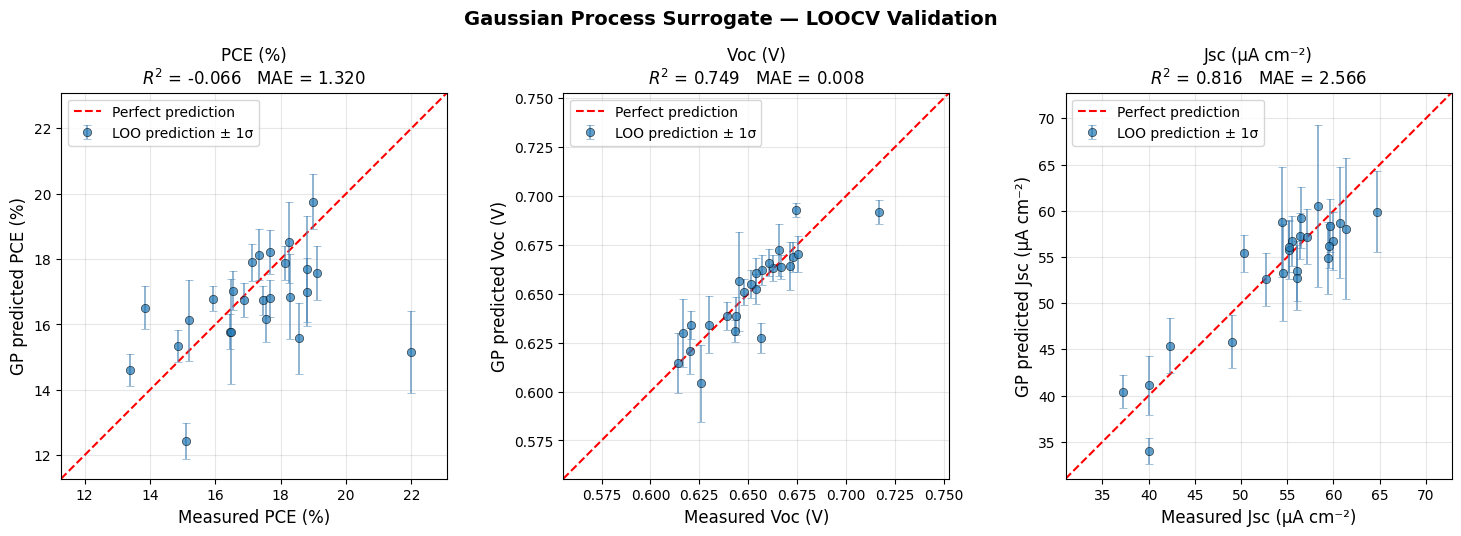

In [147]:
# Reload the full dataset
df_loocv = pd.read_csv('./data-bo-dssc.tsv', sep='\t', decimal=',')
scaler = StandardScaler()
X_all = df_loocv[['I2', 'LiI', 'BMII', 'TBP', 'GuSCN']].values
X_all = scaler.fit_transform(X_all)

targets_loocv = {
    'PCE (%)':        df_loocv['PCE(%)'].values,
    'Voc (V)':        df_loocv['Voc(V)'].values,
    'Jsc (µA cm⁻²)': df_loocv['Jsc(uAcm-2)'].values,
}

# Per-target kernels, matching those used during optimisation
kernels_loocv = {
    'PCE (%)': (
        ConstantKernel(3.5, (1e-3, 1e1))
        * Matern(length_scale=3 * np.ones(5), length_scale_bounds=(1e-4, 1e1), nu=2.5)
        + WhiteKernel(noise_level=0.3, noise_level_bounds=(1e-6, 1e-3))
    ),
    'Voc (V)': (
        ConstantKernel(1e-3, (1e-5, 1e-1))
        * Matern(length_scale=np.ones(5), length_scale_bounds=(1e-2, 5*1e1), nu=2.5)
        + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-6, 1e-1))
    ),
    'Jsc (µA cm⁻²)': (
        ConstantKernel(1e2, (1e-1, 1e3))
        * Matern(length_scale=np.ones(5), length_scale_bounds=(1e-2, 1e1), nu=2.5)
        + WhiteKernel(noise_level=1e0, noise_level_bounds=(1e-6, 1e1))
    ),
}

loo = LeaveOneOut()
loocv_results = {}

for target_name, y_all in targets_loocv.items():
    y_true, y_pred_loo, y_std_loo = [], [], []
    kernel = kernels_loocv[target_name]

    for train_idx, test_idx in loo.split(X_all):
        X_train, X_test = X_all[train_idx], X_all[test_idx]
        y_train, y_test = y_all[train_idx], y_all[test_idx]

        gp = GaussianProcessRegressor(
            kernel=kernel,
            n_restarts_optimizer=20,
            random_state=42,
            normalize_y=False
        )
        gp.fit(X_train, y_train)
        pred, std = gp.predict(X_test, return_std=True)

        y_true.append(y_test[0])
        y_pred_loo.append(pred[0])
        y_std_loo.append(std[0])
        print(gp.log_marginal_likelihood_value_)

    y_true = np.array(y_true)
    y_pred_loo = np.array(y_pred_loo)
    y_std_loo = np.array(y_std_loo)
    loocv_results[target_name] = (y_true, y_pred_loo, y_std_loo)

    r2 = np.corrcoef(y_true, y_pred_loo)[0, 1] ** 2
    mae = mean_absolute_error(y_true, y_pred_loo)
    print(f"{target_name:20s}  R² = {r2:.4f}   MAE = {mae:.4f}")
    print(f"Optimised kernel for {target_name}: {gp.kernel_}\n")

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (target_name, (y_true, y_pred_loo, y_std_loo)) in zip(axes, loocv_results.items()):
    if target_name == 'PCE (%)':
        results = pd.DataFrame({
            'True': y_true,
            'Predicted': y_pred_loo,
            'Std': y_std_loo
        })
        results.to_csv(f'./results-loocv-{target_name}.csv', index=False)
    r2  = r2_score(y_true, y_pred_loo)
    mae = mean_absolute_error(y_true, y_pred_loo)

    lims = [min(y_true.min(), (y_pred_loo - y_std_loo).min()) * 0.95,
            max(y_true.max(), (y_pred_loo + y_std_loo).max()) * 1.05]

    ax.errorbar(
        y_true, y_pred_loo,
        yerr=y_std_loo,
        fmt='o', alpha=0.7,
        ecolor='steelblue', elinewidth=1.2, capsize=3,
        markeredgecolor='k', markeredgewidth=0.5,
        zorder=3, label='LOO prediction ± 1σ'
    )
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel(f'Measured {target_name}', fontsize=12)
    ax.set_ylabel(f'GP predicted {target_name}', fontsize=12)
    ax.set_title(f'{target_name}\n$R^2$ = {r2:.3f}   MAE = {mae:.3f}', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')

plt.suptitle('Gaussian Process Surrogate — LOOCV Validation', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()